# MLP Classifier From Scratch

A feed-forward MLP built from tensor primitives only: the forward pass, loss, backprop and optimiser are all written from scratch.

**Datasets:** two moons (2D, used for visuals and diagnostics) and MNIST (784-D, 10 classes, the focus problem).

## 1. Setup

In [116]:
# Colab: torch, torchvision, sklearn and matplotlib come preinstalled.
# Locally: use the .venv with the CUDA build of torch (cu126).
import time

import numpy as np
import matplotlib.pyplot as plt
import torch

# Data only: make_moons generates two moons; torchvision just downloads MNIST (.data/.targets tensors).
from sklearn.datasets import make_moons
from torchvision.datasets import MNIST

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)
print("device:", device, "| torch", torch.__version__)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

device: cuda | torch 2.14.0+cu126
GPU: NVIDIA GeForce RTX 4080 SUPER


## 2. Data
Both datasets are loaded, split and moved to `device` once here. Later sections slice these tensors and never reload the data.

**Split rule:** *train* fits the weights θ; *val* chooses hyperparameters (width, learning rate, batch size, epochs); *test* is used **once**, at the very end. Tuning on test would make the test score an overly optimistic estimate of performance on new data.

### 2.1 Two moons
Two interleaving half-circles in 2D (`make_moons`, 1000 points, noise 0.2). They are **not linearly separable**: no straight line splits them, which is why the model needs a hidden layer. Because the data is 2D, any function the model computes can be drawn as a picture, which the hypothesis-set section uses.

- **Input** `x`: float32, shape `(2,)`; a batch is `(B, 2)`. Values already lie in a small range (about [-1.5, 2.5] × [-1, 1.5]), so no scaling is needed.
- **Label** `y`: int64 in {0, 1} (which moon); a batch is `(B,)`.
- **Split:** 70 / 15 / 15 → 700 / 150 / 150.
- **Model output:** 2 **logits** per point, shape `(B, 2)`: unnormalised scores, one per class. Softmax turns them into probabilities that sum to 1; the prediction is the argmax.
- **Deployment:** one point `(2,)` in → 2 class probabilities → predicted moon (0 or 1).

train (700, 2) | val (150, 2) | test (150, 2)
dtypes: torch.float32 torch.int64 | class counts (train): [364, 336]


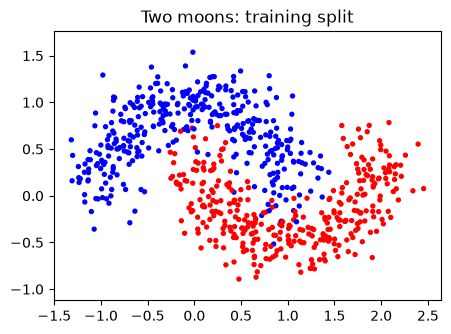

In [117]:
# make_moons returns NumPy (float64 X, int64 y); convert to the dtypes the model expects.
X_np, y_np = make_moons(n_samples=1000, noise=0.2, random_state=SEED)
X = torch.from_numpy(X_np).float()     # (1000, 2) float32
y = torch.from_numpy(y_np).long()      # (1000,) int64 in {0, 1}

# Shuffle once, then cut: a fixed, reproducible split. Own generator so the split
# doesn't depend on how many random numbers earlier cells used.
g = torch.Generator().manual_seed(SEED)
perm = torch.randperm(len(X), generator=g)                    # (1000,) a permutation of 0..999
i_tr, i_va, i_te = perm[:700], perm[700:850], perm[850:]
Xtr, ytr = X[i_tr].to(device), y[i_tr].to(device)             # (700, 2), (700,)
Xva, yva = X[i_va].to(device), y[i_va].to(device)             # (150, 2), (150,)
Xte, yte = X[i_te].to(device), y[i_te].to(device)             # (150, 2), (150,)

print("train", tuple(Xtr.shape), "| val", tuple(Xva.shape), "| test", tuple(Xte.shape))
print("dtypes:", Xtr.dtype, ytr.dtype, "| class counts (train):", torch.bincount(ytr).tolist())

plt.figure(figsize=(5, 3.5))
plt.scatter(*Xtr.cpu().T, c=ytr.cpu(), cmap="bwr", s=8)       # matplotlib needs CPU data
plt.title("Two moons: training split"); plt.axis("equal"); plt.show()

### 2.2 MNIST
28×28 greyscale handwritten digits, 10 classes. The focus problem.

- **Raw:** images `uint8` in [0, 255], shape `(28, 28)`; labels `int64` in {0, …, 9}.
- **Preprocessing (ours):** cast to float32, divide by 255 → [0, 1], flatten → `(784,)`. A batch is `(B, 784)`.
- **Split:** the official 60k training set is shuffled once and cut into 50k train / 10k val. The official 10k test set is the test split, used once.
- **Model output:** 10 **logits** per image, shape `(B, 10)`. Softmax turns them into probabilities over the digits 0–9; the prediction is the argmax.
- **Deployment:** one 28×28 greyscale image, preprocessed the same way (÷255, flatten to `(784,)`) → 10 probabilities → predicted digit.

In [118]:
mnist_train = MNIST(root="data", train=True,  download=True)   # official 60k training set
mnist_test  = MNIST(root="data", train=False, download=True)   # official 10k test set
# Only the raw tensors are used: no transforms, no DataLoader.
raw = {"train_x": mnist_train.data, "train_y": mnist_train.targets,   # (60000, 28, 28) uint8, (60000,) int64
       "test_x":  mnist_test.data,  "test_y":  mnist_test.targets}    # (10000, 28, 28) uint8, (10000,) int64
print({k: (tuple(v.shape), v.dtype) for k, v in raw.items()})

{'train_x': ((60000, 28, 28), torch.uint8), 'train_y': ((60000,), torch.int64), 'test_x': ((10000, 28, 28), torch.uint8), 'test_y': ((10000,), torch.int64)}


train (50000, 784) | val (10000, 784) | test (10000, 784)
dtypes: torch.float32 torch.int64 | pixel range [0, 1]
train class counts: [4866, 5643, 5009, 5139, 4853, 4491, 4933, 5181, 4896, 4989]


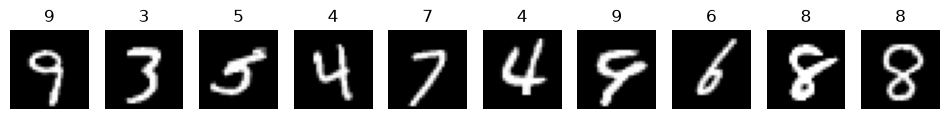

In [119]:
def preprocess(images):
    # (N, 28, 28) uint8 in [0, 255] -> (N, 784) float32 in [0, 1].
    # Scaling to [0, 1] keeps first-layer pre-activations small at init; flattening makes each image one row of X.
    return images.float().div(255).reshape(len(images), -1)

X_all, y_all = preprocess(raw["train_x"]), raw["train_y"]          # (60000, 784), (60000,)
g = torch.Generator().manual_seed(SEED)
perm = torch.randperm(60_000, generator=g)                         # same shuffle as the prototype
mX_tr, my_tr = X_all[perm[:50_000]].to(device), y_all[perm[:50_000]].to(device)   # (50000, 784), (50000,)
mX_va, my_va = X_all[perm[50_000:]].to(device), y_all[perm[50_000:]].to(device)   # (10000, 784), (10000,)
mX_te, my_te = preprocess(raw["test_x"]).to(device), raw["test_y"].to(device)     # (10000, 784), (10000,)

print("train", tuple(mX_tr.shape), "| val", tuple(mX_va.shape), "| test", tuple(mX_te.shape))
print("dtypes:", mX_tr.dtype, my_tr.dtype, f"| pixel range [{mX_tr.min():.0f}, {mX_tr.max():.0f}]")
print("train class counts:", torch.bincount(my_tr).tolist())

# Sanity check: the parse is right if the images look like digits and match their labels.
fig, axes = plt.subplots(1, 10, figsize=(12, 1.6))
for ax, i in zip(axes, range(10)):
    ax.imshow(mX_tr[i].reshape(28, 28).cpu(), cmap="gray")
    ax.set_title(int(my_tr[i])); ax.axis("off")
plt.show()

## 3. Model
The model is a function $f_\theta$: a batch of inputs in, one **logit** per class out. §3.1 builds it; §3.2 studies the set of all functions it can be.

### 3.1 Forward pass
**Architecture (working model):** one hidden layer with ReLU. Two moons: **2 → 16 → 2**. MNIST: **784 → 128 → 10**.

> **Widths.** 16 and 128 are the starting points used in §3–§6.5. MNIST's tuned hidden layer width, **768**, is chosen on the validation split in §6.6, with lr and batch size: 6× the parameters of the working model. Moons keeps 16: it is the 2D picture, not the focus problem, so it is not tuned.

**Parameters θ.** The four tensors are kept in one dict, `params = {"W1": ..., "b1": ..., "W2": ..., "b2": ...}`.

Each weight matrix has **one row per input and one column per neuron**, so its shape is `(inputs, neurons)`. For example, moons' W1 is `(2, 16)`: 2 input features, 16 hidden neurons. Column j holds the weights feeding into neuron j. This shape makes the matrix product line up with no transpose: `(B, 2) @ (2, 16) → (B, 16)`.

| Parameter | Shape | Two moons | MNIST, working (§3–6.5) | MNIST, tuned (§6.6-7) |
|---|---|---|---|---|
| `W1` | `(d_in, d_hid)` | 2 × 16 = 32 | 784 × 128 = 100,352 | 784 × 768 = 602,112 |
| `b1` | `(d_hid,)` | 16 | 128 | 768 |
| `W2` | `(d_hid, d_out)` | 16 × 2 = 32 | 128 × 10 = 1,280 | 768 × 10 = 7,680 |
| `b2` | `(d_out,)` | 2 | 10 | 10 |
| **Total** | | **82** | **101,770** | **610,570** |

**Initialisation: He.** $W \sim \mathcal{N}(0,\, 2/d_{in})$ and $b = 0$. The variance 2/d_in keeps the size of each layer's pre-activations roughly constant through ReLU, which zeroes about half its inputs (hence the 2). Biases can start at 0 because the random W already makes every hidden neuron different.

In [120]:
def init_params(d_in, d_hid, d_out, gen):
    # Returns {"W1": (d_in, d_hid), "b1": (d_hid,), "W2": (d_hid, d_out), "b2": (d_out,)}, float32, on `device`.
    # `gen` is a CPU torch.Generator: draw on the CPU, then .to(device). A CPU generator can't
    # draw directly onto the GPU, and this way the same seed gives the same θ on CPU and GPU.
    # He init: randn draws N(0, 1); scaling by std gives N(0, std²), since Var(cX) = c²·Var(X).
    W1 = torch.randn(d_in, d_hid, generator=gen) * (2 / d_in) ** 0.5     # (d_in, d_hid), std = √(2 / fan-in)
    W2 = torch.randn(d_hid, d_out, generator=gen) * (2 / d_hid) ** 0.5   # (d_hid, d_out), fan-in of layer 2 is d_hid
    b1 = torch.zeros(d_hid)                                              # (d_hid,)
    b2 = torch.zeros(d_out)                                              # (d_out,)
    params = {"W1": W1, "b1": b1, "W2": W2, "b2": b2}
    return {name: p.to(device) for name, p in params.items()}

**Forward pass** (one row per example, B rows per batch):

$$Z_1 = XW_1 + b_1, \qquad A_1 = \text{ReLU}(Z_1) = \max(Z_1, 0), \qquad Z_2 = A_1W_2 + b_2$$

`forward` returns the logits `Z2` **and a cache `(Z1, A1)`**. Backprop (§5) needs Z1 for the ReLU mask and A1 for dW2, so we save them here and don't recompute them there. Softmax is not part of the model; it lives in the loss (§4).

In [121]:
def relu(Z):
    # Element-wise max(Z, 0): negatives become 0, positives pass through. Same shape in and out.
    return Z.clamp(min=0)


def forward(X, params):
    # (B, d_in) -> logits (B, d_out), plus cache (Z1, A1) for backprop.
    Z1 = X @ params["W1"] + params["b1"]     # (B, d_in) @ (d_in, d_hid) -> (B, d_hid); b1 (d_hid,) broadcasts to every row
    A1 = relu(Z1)                            # (B, d_hid)
    Z2 = A1 @ params["W2"] + params["b2"]    # (B, d_hid) @ (d_hid, d_out) -> (B, d_out); logits, no softmax (§4)
    return Z2, (Z1, A1)

**Check 1: by hand.** A 2 → 2 → 2 network with integer weights, computed on paper, then compared with `forward`. The gradient check (§5.3) can't catch a wrong forward pass, because it only tests that backprop matches the forward pass as written. So the forward pass gets its own check.

For x = [1, 2]: Z1 = [1·1 + 2·2, 1·(−1) + 2·(−3)] + [−1, 1] = **[4, −6]**. ReLU turns this into A1 = **[4, 0]**, so hidden neuron 2 is off. Then Z2 = [4·1 + 0·3, 4·(−1) + 0·2] + [0, 1] = **[4, −3]**. The second row, x = [0, 1], works the same way and gives Z2 = [1, 0].

**Check 2: real shapes.** Initialise both real networks, run a batch through each, and confirm the output shapes and parameter counts match the table above.

In [122]:
# Check 1: the hand example, as a batch of 2 rows (so the b1 broadcast over rows is tested too).
hand = {k: torch.tensor(v, dtype=torch.float32, device=device) for k, v in {
    "W1": [[1., -1.], [2., -3.]], "b1": [-1., 1.],
    "W2": [[1., -1.], [3., 2.]],  "b2": [0., 1.]}.items()}
Xh = torch.tensor([[1., 2.], [0., 1.]], device=device)          # (2, 2)
Z2h, (Z1h, A1h) = forward(Xh, hand)
assert torch.equal(Z1h, torch.tensor([[4., -6.], [1., -2.]], device=device))
assert torch.equal(A1h, torch.tensor([[4., 0.], [1., 0.]], device=device))
assert torch.equal(Z2h, torch.tensor([[4., -3.], [1., 0.]], device=device))
print("hand check passed: Z2 =", Z2h.tolist())

# Check 2: real networks. Own generator, so θ depends only on SEED.
g = torch.Generator().manual_seed(SEED)
for name, X_, dims in [("moons", Xtr, (2, 16, 2)), ("MNIST", mX_va, (784, 128, 10))]:
    params = init_params(*dims, gen=g)
    Z2, (Z1, A1) = forward(X_, params)
    n_params = sum(p.numel() for p in params.values())
    print(f"{name}: X {tuple(X_.shape)} -> Z1 {tuple(Z1.shape)} -> Z2 {tuple(Z2.shape)} | "
          f"{n_params:,} params | W1 std {params['W1'].std():.4f} (target {(2 / dims[0]) ** 0.5:.4f})")

hand check passed: Z2 = [[4.0, -3.0], [1.0, 0.0]]
moons: X (700, 2) -> Z1 (700, 16) -> Z2 (700, 2) | 82 params | W1 std 1.0223 (target 1.0000)
MNIST: X (10000, 784) -> Z1 (10000, 128) -> Z2 (10000, 10) | 101,770 params | W1 std 0.0506 (target 0.0505)


### 3.2 Hypothesis set ℋ
The architecture fixes the **shape** of every function the model can compute; the parameters θ pick out **one** function.

**Logit function** (this is exactly `forward`), for one input row x of shape `(d_in,)`:

$$f_\theta(x) = \text{ReLU}(xW_1 + b_1)\,W_2 + b_2 \;\in \mathbb{R}^{d_{out}}, \qquad \theta = (W_1, b_1, W_2, b_2)$$

**Hypothesis:** the classifier built on it, which returns the class with the highest logit (where $k$ is a class index):

$$h_\theta(x) = \arg\max_k f_\theta(x)_k$$

**Hypothesis set:** every classifier of this shape,

$$\mathcal{H} = \{\, h_\theta \;:\; \theta \in \mathbb{R}^{P} \,\}, \qquad P = 82 \text{ (moons)}, \;\; 101{,}770 \text{ (MNIST)}$$

One θ (one filled-in `params` dict) gives one member. Each parameter is a real number, so ℋ has infinitely many members. Two different θ can give the same classifier, if their logits differ but the argmax never does.

**Why two functions?** Training adjusts θ through the smooth logits $f_\theta$. Argmax is a step function with zero gradient almost everywhere, so there is nothing to follow through it. The hypothesis $h_\theta$ is what we *evaluate*: the plots and accuracies below all use it. Softmax, added in §4, turns $f_\theta(x)$ into probabilities but never changes which logit is largest, so it doesn't change $h_\theta$.

$$h_\theta(x) = \arg\max_k (\text{softmax}(f_\theta(x))_k) = \arg\max_k f_\theta(x)_k$$

**Sampling:** members below come from init_params (§3.1), so all biases are 0. They show where training starts, which is only the zero-bias part of ℋ.

**Split used to score:** None of these functions has been trained, so every split is unseen data to them. We score on **val** anyway, so that test stays untouched until the end.

#### (a) What random members look like
Eight random θ for the 2 → 16 → 2 moons network. Each one is evaluated on a dense grid of points covering the data (spacing 0.02), and each grid point is coloured by its predicted class (the argmax of the logits). The edge between the two colours is the **decision boundary**. The `+` marks the origin.

**Prediction:** all biases are 0, so f(c·x) = c·f(x) for any c > 0. That's because ReLU(c·z) = c·ReLU(z), and matrix multiplication is linear. Scaling every logit by the same positive c can't change the argmax. So the predicted class stays the same along every ray from the origin, and each member should split the plane into **wedges that meet at (0, 0)**.

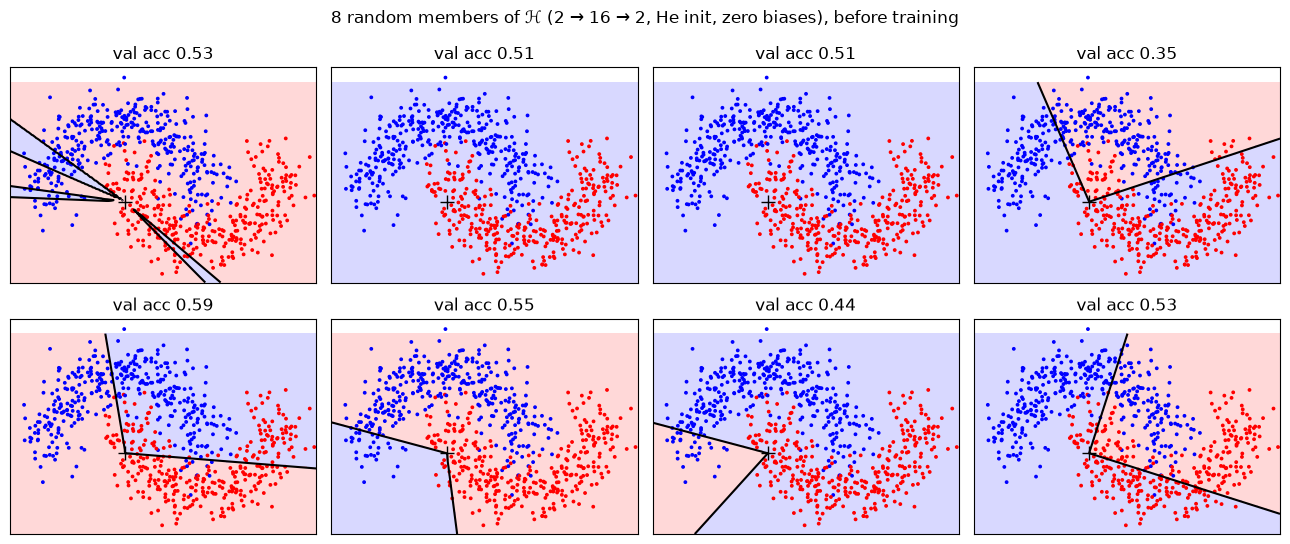

In [123]:
# Dense grid over the moons (spacing 0.02). Every grid point is one input row, so the whole grid is one batch.
xs = torch.arange(-1.5, 2.5, 0.02)                                  # (200,)
ys = torch.arange(-1.0, 1.5, 0.02)                                  # (125,)
gx, gy = torch.meshgrid(xs, ys, indexing="xy")                      # each (125, 200): x and y coordinate of every point
grid = torch.stack([gx.reshape(-1), gy.reshape(-1)], dim=1).to(device)   # (25000, 2)


def plot_members(members, fwd, title):
    # One panel per θ: predicted class over the grid, training points on top, val accuracy in the title.
    fig, axes = plt.subplots(2, 4, figsize=(13, 5.5))
    for ax, params in zip(axes.flat, members):
        Z = fwd(grid, params)[0]                                           # (25000, 2) logits
        pred = Z.argmax(dim=1).reshape(gx.shape)                           # (125, 200) class per grid point
        margin = (Z[:, 1] - Z[:, 0]).reshape(gx.shape)                     # (125, 200); boundary where z1 = z0, i.e. P = 0.5
        acc = (fwd(Xva, params)[0].argmax(dim=1) == yva).float().mean()   # fraction of val points right
        ax.contourf(gx, gy, pred.cpu(), levels=[-0.5, 0.5, 1.5], cmap="bwr", alpha=0.3)
        ax.contour(gx, gy, margin.cpu(), levels=[0], colors="k", linewidths=1.5)
        ax.scatter(*Xtr.cpu().T, c=ytr.cpu(), cmap="bwr", s=3)
        ax.plot(0, 0, "k+", ms=10)
        ax.set_title(f"val acc {acc:.2f}"); ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(title); plt.tight_layout(); plt.show()


g = torch.Generator().manual_seed(SEED)
moons_members = [init_params(2, 16, 2, gen=g) for _ in range(8)]
plot_members(moons_members, forward, "8 random members of ℋ (2 → 16 → 2, He init, zero biases), before training")

**Reading it (seed 0).**
- **The prediction holds.** Every boundary is made of straight rays meeting at the origin `+`, so the regions are wedges.
- **Why the edges bend:** each ray-edge is where one hidden ReLU switches on or off. The function is piecewise linear, with one linear piece per wedge.
- **Some members are constant** (panels 2 and 3 are all blue): class 0 wins in every direction, so the single "wedge" is the whole plane. Nothing forces a random member to use both classes.
- **Val accuracy is 0.35–0.59, around chance (0.5).** Nothing has been learned: an untrained member is a random guess with a particular shape.
- **Training's job:** move θ through ℝ⁸² until one member's wedges bend around the moons. Once the biases move off 0, the boundaries no longer have to pass through the origin.

#### (b) Remove ReLU and ℋ collapses to linear models
Take the **same eight θ** and delete the activation. The two layers then compose into one linear layer:

$$(XW_1 + b_1)W_2 + b_2 \;=\; X\,\underbrace{(W_1W_2)}_{W:\;(d_{in},\, d_{out})} \;+\; \underbrace{(b_1W_2 + b_2)}_{b:\;(d_{out})}$$

Composing linear maps gives a linear map, so the hidden layer adds nothing: every member is a single-layer linear classifier, and every boundary is a **straight line**. (Here it passes through the origin too, because the biases are 0.) No straight line separates the moons, so no θ in this collapsed ℋ can solve the task. ReLU is what makes the hidden layer worth having.

The code checks the collapse numerically: the no-ReLU network and the single matrix W = W1 @ W2 give the same logits.

collapse check passed: no-ReLU network == one linear layer, W shape (2, 2)


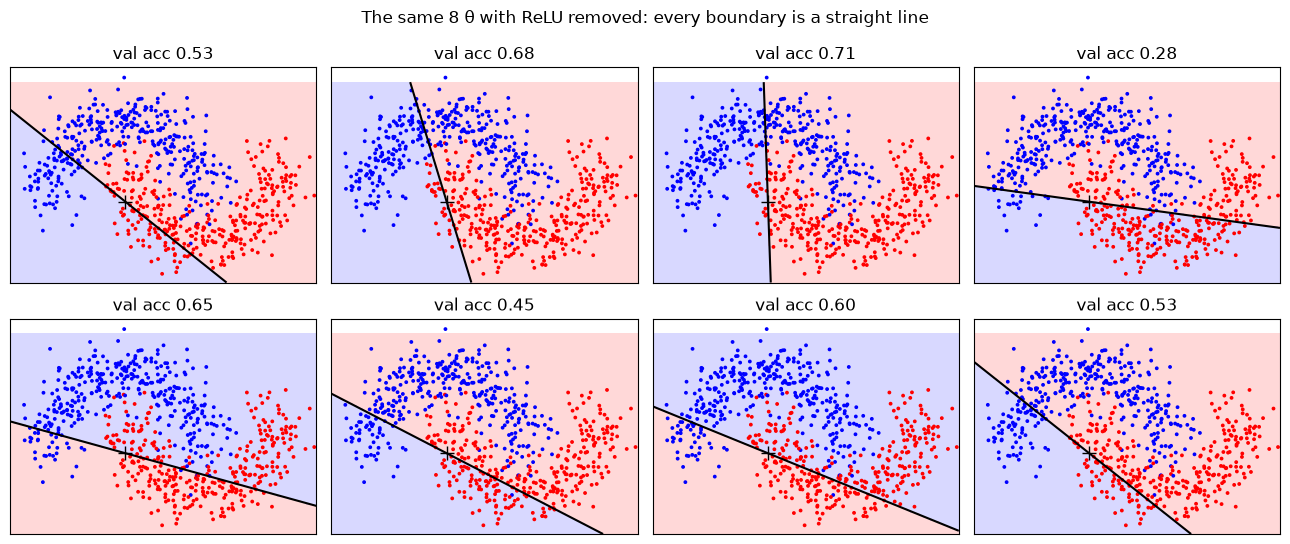

In [124]:
def forward_no_relu(X, params):
    # forward() with the activation deleted. Used only here, to show the collapse.
    Z1 = X @ params["W1"] + params["b1"]     # (B, d_hid)
    Z2 = Z1 @ params["W2"] + params["b2"]    # (B, d_out)
    return Z2, (Z1, Z1)


# The collapse, numerically: two layers without ReLU = one layer with W = W1 @ W2, b = b1 @ W2 + b2.
p = moons_members[0]
W, b = p["W1"] @ p["W2"], p["b1"] @ p["W2"] + p["b2"]               # (2, 2), (2,)
assert torch.allclose(forward_no_relu(grid, p)[0], grid @ W + b, atol=1e-5)   # float32 rounding differs slightly
print("collapse check passed: no-ReLU network == one linear layer, W shape", tuple(W.shape))

plot_members(moons_members, forward_no_relu, "The same 8 θ with ReLU removed: every boundary is a straight line")

**Reading it.**
- **Every boundary is now a single straight line through the origin.** The numerical check confirms that each of these networks *is* the one-layer model X·W + b.
- **Some of these score higher than the ReLU members above** (up to 0.71). That is luck at initialisation, not an advantage. What matters is where training can reach. With ReLU it can bend the boundary around the moons. Without ReLU, the best any θ can do is the best straight line.

## 4. Loss (softmax + cross-entropy)
The loss scores a batch of logits against the true labels as **one number: lower is better**. It must change smoothly as the weights θ change, so backprop (§5) has a gradient to follow. Accuracy can't do this job: it goes through argmax, which is a step function (§3.2), so its gradient is 0 almost everywhere. Cross-entropy is the smooth stand-in we train on; accuracy is still what we report.

### 4.1 Softmax and cross-entropy
**Softmax: logits → probabilities.** For example (row) $i$ and class $k$:

$$p_{ik} = \frac{e^{z_{ik}}}{\sum_j e^{z_{ij}}}$$

$e^z$ makes every score positive and keeps their order; dividing by the row's sum makes each row sum to 1. Example: z = [2, 0.5, −1] → e^z = [7.39, 1.65, 0.37], sum 9.41 → **p = [0.786, 0.175, 0.039]**.

**Cross-entropy: probabilities → one number.** Labels are one-hot: $Y_{ik} = 1$ if example $i$ is class $k$, else 0. For a batch of $B$ examples and $K$ classes:

$$L(\theta) = -\frac{1}{B}\sum_{i=1}^{B}\sum_{k=1}^{K} Y_{ik}\,\log p_{ik} \;=\; -\frac{1}{B}\sum_{i=1}^{B}\log p_{i,\,y_i}$$

Each one-hot row zeroes every term except the true class, so each example adds **−log p(true class)**. For the z above: true class 0 gives 0.241; true class 2 gives **3.241**. The model is the same, only the label differs.

**Why −log p:**
- **Confident mistakes cost the most.** −log p is 0 at p = 1 and grows without bound as p → 0, so one badly wrong example (p = 0.01 → 4.61) outweighs ten good ones (p = 0.8 → 0.22 each).
- **Maximum likelihood.** The probability the model gives to all the batch's labels at once is the product $\prod_i p_{i,y_i}$ (the likelihood). $-\sum_i \log p_{i,y_i} = -\log \prod_i p_{i,y_i}$, and log is increasing, so **minimising CE = maximising the likelihood**. The log form also doesn't underflow: 0.97^50,000 is 0 in float32, while its log (−1523) is an ordinary number.
- **Mean, not sum:** dividing by B keeps the loss, and so the gradient's scale, independent of the batch size. The learning rate then doesn't need retuning when B changes.

**Expected value before training:** an untrained model is close to uniform, p ≈ 1/K, so **L ≈ log K**: 0.693 for moons (K = 2), 2.303 for MNIST (K = 10). A starting loss far from this points to a bug upstream (e.g. the init scale).

### 4.2 Numerical stability
float32 overflows above about $e^{88.7}$ and rounds anything below about $e^{-104}$ to 0. The textbook formula breaks on logits that training can reach:

| Logits | Naive result | True answer |
|---|---|---|
| [1000, 999] | e^z = [inf, inf] → p = inf/inf = **nan** | p = [0.731, 0.269] |
| [0, −200], true class 1 | p₁ = e^−200 → 0 → loss −log 0 = **inf** | loss = 200 |

A single nan in the loss becomes nan in every gradient and then in every weight, which ends training.

Two facts fix it:
1. **Shift invariance.** For any constant $c$, $\text{softmax}(z - c) = \text{softmax}(z)$, because $e^{-c}$ factors out of the top and the bottom and cancels. Only the gaps between logits matter.
2. **Log space.** Taking the log of softmax turns the division into a subtraction, so the tiny $p$ never has to be formed before its log is taken.

With $m_i = \max_j z_{ij}$, the max of row $i$:

$$\log p_{ik} = (z_{ik} - m_i) \;-\; \log \sum_j e^{\,z_{ij} - m_i}$$

- **No overflow:** every exponent $z_{ij} - m_i \le 0$, so every term is at most 1.
- **Safe log:** the row's max contributes $e^0 = 1$, so the sum lies in $[1, K]$ and its log in $[0, \log K]$.
- **No log 0:** the true class's score enters as the plain number $z_{ik} - m_i$, never through $e$. On [0, −200]: log p₁ = (−200 − 0) − log(1 + e^−200) = −200 − 0 = −200, so the loss is 200.

**m must be per row.** A single batch-wide max is still correct on paper (shift invariance holds for any constant), but only the row that holds it is guaranteed its $e^0 = 1$. In `[[1000, 999], [-500, -501]]`, row 2 shifted by 1000 is [−1500, −1501]: both terms underflow to 0, log 0 = −∞, and the loss is nan.

**Code layout.**
- `log_softmax(Z)` is the only function with the max trick in it.
- `softmax(Z)` is `exp(log_softmax(Z))`, so it inherits the stability.
- `cross_entropy(Z2, Y)` returns **(L, P)**. Backprop needs P, since $\partial L / \partial Z_2 = (P - Y)/B$ (§5), and returning it mirrors `forward`'s cache.
- Labels stay int64 from §2; `one_hot` builds Y when the loss needs it.
- Predictions don't need softmax: they are the argmax of the logits (§3.2).

In [125]:
def log_softmax(Z):
    # (B, K) logits -> (B, K) log-probabilities. Stable: shift each row by its own max first (§4.2).
    m = Z.max(dim=1, keepdim=True).values                              # (B, 1) row max; keepdim so it broadcasts across the K columns
    shifted = Z - m                                                    # (B, K) every entry <= 0, each row's max is exactly 0
    return shifted - torch.log(torch.exp(shifted).sum(dim=1, keepdim=True))   # (B, K) - (B, 1); each row sum is in [1, K], so the log is safe


def softmax(Z):
    # (B, K) logits -> (B, K) probabilities, each row sums to 1. Built on log_softmax so the stability lives in one place.
    return torch.exp(log_softmax(Z))


def one_hot(y, K):
    # (B,) int64 labels -> (B, K) float: row i is all 0 except a 1 in column y[i].
    Y = torch.zeros(len(y), K, device=y.device)
    Y[torch.arange(len(y), device=y.device), y] = 1.0                  # pairs (0, y[0]), (1, y[1]), ...: one entry per row
    return Y


def cross_entropy(Z2, Y):
    # (B, K) logits, (B, K) one-hot -> mean loss L (scalar), and P (B, K), which backprop needs for dZ2 = (P - Y) / B.
    logP = log_softmax(Z2)                                             # (B, K)
    L = -(Y * logP).sum(dim=1).mean()                                  # (B, K) -> (B,) -log p(true class) per example -> scalar mean
    return L, torch.exp(logP)                                          # P from the same logP: no second log_softmax

### 4.3 Checks
The gradient check (§5.3) only tests backprop against this loss, so the loss needs its own check. **By hand:** the §4.1 examples (0.2413, 3.2413) and a 2-row batch, (0.241 + 1.099) / 2 = 0.670, with each row of P summing to 1. **Stability:** the §4.2 cases give the true answers (0.3133, 200) instead of nan or inf.

In [126]:
def ce(Z, labels):
    # Test helper: plain lists in, (L as float, P) out.
    Z = torch.tensor(Z, device=device)
    L, P = cross_entropy(Z, one_hot(torch.tensor(labels, device=device), Z.shape[1]))
    return L.item(), P

# By hand.
assert abs(ce([[2., 0.5, -1.]], [0])[0] - 0.2413) < 1e-4
assert abs(ce([[2., 0.5, -1.]], [2])[0] - 3.2413) < 1e-4
L, P = ce([[2., 0.5, -1.], [0., 0., 0.]], [0, 1])
assert abs(L - 0.6700) < 1e-4
assert torch.allclose(P.sum(dim=1), torch.ones(2, device=device))    # each row is a distribution

# Stability: the naive formula gives nan (line 1) and inf (line 2); see §4.2.
assert abs(ce([[1000., 999.]], [0])[0] - 0.3133) < 1e-3
assert abs(ce([[0., -200.]], [1])[0] - 200.0) < 1e-3
print("loss checks passed")

loss checks passed


## 5. Backprop
Training needs, for every parameter, $\partial L / \partial \theta$: which way and how steeply the loss changes as that parameter moves. Backprop computes all of them in one backward pass, by applying the chain rule to the forward pass's steps in reverse order.

**Notation.** $dX$ means $\partial L / \partial X$ and always has the shape of $X$. Layers are counted by their weights: layer 1 is $(W_1, b_1)$, layer 2 is $(W_2, b_2)$; the input has no parameters, so it is not a layer here.

### 5.1 The chain rule, step by step
**Chain rule with several paths.** If $w$ reaches $L$ through several intermediate values $z$, add one product per path: $\;\dfrac{\partial L}{\partial w} = \sum_{\text{paths}} \dfrac{\partial L}{\partial z} \cdot \dfrac{\partial z}{\partial w}$.

**Step 1: the loss.** For one example with true class $y$, write the loss without the fraction (this is exactly `log_softmax`):

$$L = -\log p_y = -z_y + \log \sum_j e^{z_j}$$

Differentiate by one logit $z_k$: the first term gives $-y_k$ (1 only when $k = y$), the second gives $e^{z_k} / \sum_j e^{z_j} = p_k$. So $\partial L / \partial z_k = p_k - y_k$. The batch loss is a mean, so each example's logits carry a factor $1/B$:

$$dZ_2 = \frac{P - Y}{B} \qquad (B, K)$$

For the true class $p_y - 1 < 0$, so gradient descent raises that logit, harder the more wrong the model is; every other logit is lowered in proportion to the probability it holds.

**Steps 2–5: two local rules**, one per kind of forward operation.

| Forward operation | Backward rule | Why |
|---|---|---|
| Linear: $Z = AW + b$ | $dW = A^\top dZ$ | each weight: (its input) × (error at its output), summed over the batch, since every example uses the same weights |
| | $db = \sum_i dZ_{i,:}$ | a bias is a weight whose input is always 1 |
| | $dA = dZ\,W^\top$ | each input: (its outgoing weights) × (errors they feed), summed over the classes it feeds |
| ReLU: $A = \max(Z, 0)$ | $dZ = dA \odot \mathbb{1}[Z > 0]$ | a gate: the gradient passes where the unit was on and is blocked where it was off |

**The whole backward pass** (the forward pass read bottom-up):

$$
\begin{array}{rlll}
\# & \textbf{Line} & \textbf{Rule} & \textbf{Shape} \\ \hline
1 & dZ_2 = (P - Y)/B & \text{loss} & (B, K) \\
2 & dW_2 = A_1^\top dZ_2 & \text{linear, weight} & (d_{hid}, K) \\
3 & db_2 = \textstyle\sum_i (dZ_2)_{i,:} & \text{linear, bias} & (K,) \\
4 & dA_1 = dZ_2 W_2^\top & \text{linear, input} & (B, d_{hid}) \\
5 & dZ_1 = dA_1 \odot \mathbb{1}[Z_1 > 0] & \text{ReLU} & (B, d_{hid}) \\
6 & dW_1 = X^\top dZ_1 & \text{linear, weight} & (d_{in}, d_{hid}) \\
7 & db_1 = \textstyle\sum_i (dZ_1)_{i,:} & \text{linear, bias} & (d_{hid},)
\end{array}
$$

**Details that are easy to get wrong:**
- **No second $1/B$.** It enters once, in $dZ_2$; every later gradient is built from $dZ_2$ and carries it. The batch sums in lines 2, 3, 6, 7 therefore give the *mean* over examples.
- **The transposes** are forced by shape: e.g. $dW_1$ must be $(d_{in}, d_{hid})$ from $X$ $(B, d_{in})$ and $dZ_1$ $(B, d_{hid})$, and only $X^\top dZ_1$ fits. The shared $B$ in the middle is the sum over examples.
- **ReLU'(0)** is undefined; we use 0. An exact 0 almost never occurs in floating point.
- **No $dX$**: $X$ is data, never updated, so the pass stops at layer 1.
- **Dead units:** a hidden unit off ($z \le 0$) on every example gets a zero gradient forever. He init keeps about half the units on for any input at the start.

### 5.2 Code
`backward` takes $dZ_2$ from the caller instead of computing it from $P$ and $Y$. The loss owns its own gradient ($dZ_2$, row 1 of the §5.1 table); `backward` owns rows 2–7 ($dW_2$ to $db_1$), which are the same for any loss. It returns a dict with the same keys as `params`, so the SGD update in §6 is one loop over the keys.

In [127]:
def backward(X, dZ2, cache, params):
    # dZ2 = dL/dZ2 (B, d_out) from the loss -> grads {"W1", "b1", "W2", "b2"}, each the shape of its parameter.
    # Each line is one chain-rule step from §5.1, in reverse order of forward().
    Z1, A1 = cache
    dW2 = A1.T @ dZ2                   # (d_hid, B) @ (B, d_out) -> (d_hid, d_out); sums over the batch, 1/B is already in dZ2
    db2 = dZ2.sum(dim=0)               # (B, d_out) -> (d_out,)
    dA1 = dZ2 @ params["W2"].T         # (B, d_out) @ (d_out, d_hid) -> (B, d_hid); error sent back to each hidden unit
    dZ1 = dA1 * (Z1 > 0)               # (B, d_hid); ReLU gate: bool mask acts as 1/0, ReLU'(0) taken as 0
    dW1 = X.T @ dZ1                    # (d_in, B) @ (B, d_hid) -> (d_in, d_hid)
    db1 = dZ1.sum(dim=0)               # (B, d_hid) -> (d_hid,)
    return {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2}

### 5.3 Gradient check
`backward` is the one component without a hand check, so we test it directly. For each weight, **nudge it up and down by a tiny $\varepsilon$ and measure how much the loss moves**. That measured slope must match what `backward` returned:

$$\frac{\partial L}{\partial \theta} \approx \frac{L(\theta + \varepsilon) - L(\theta - \varepsilon)}{2\varepsilon}$$

This runs on the moons network (82 parameters, every one checked) in **float64**: the loss changes by only about $10^{-5}$ per nudge, and float32's rounding (about $10^{-7}$ of the value) would blur that difference.

**What a pass shows:** `backward` gives the true slope of the loss *as `forward` and `cross_entropy` are coded*. It cannot catch a bug in those two; §3.1 and §4.3 check them.

In [128]:
def numerical_grads(X, Y, params, eps=1e-5):
    # Slope of the loss for every parameter entry, measured by nudging it: (L(θ + ε) - L(θ - ε)) / 2ε.
    num = {}
    for name, W in params.items():
        num[name] = torch.zeros_like(W)
        flat, num_flat = W.view(-1), num[name].view(-1)      # views: writing flat[j] edits W in place
        for j in range(len(flat)):
            old = flat[j].item()
            flat[j] = old + eps; L_plus = cross_entropy(forward(X, params)[0], Y)[0]
            flat[j] = old - eps; L_minus = cross_entropy(forward(X, params)[0], Y)[0]
            flat[j] = old                                     # restore
            num_flat[j] = (L_plus - L_minus) / (2 * eps)
    return num


params = {name: p.double() for name, p in init_params(2, 16, 2, torch.Generator().manual_seed(SEED)).items()}
Xg, Yg = Xtr[:8].double(), one_hot(ytr[:8], 2).double()                  # (8, 2), (8, 2)
Z2, cache = forward(Xg, params)
_, P = cross_entropy(Z2, Yg)
grads = backward(Xg, (P - Yg) / len(Xg), cache, params)                  # dZ2 = (P - Y) / B
num = numerical_grads(Xg, Yg, params)
for name in params:
    diff = (grads[name] - num[name]).abs().max().item()
    assert grads[name].shape == params[name].shape and diff < 1e-7, name
    print(f"{name}: shape {tuple(grads[name].shape)}, max |backward - measured| = {diff:.1e}")
print("All parameters within 1e-7 -> gradient check passed")

W1: shape (2, 16), max |backward - measured| = 1.5e-11
b1: shape (16,), max |backward - measured| = 1.2e-11
W2: shape (16, 2), max |backward - measured| = 2.0e-11
b2: shape (2,), max |backward - measured| = 2.9e-12
All parameters within 1e-7 -> gradient check passed


## 6. Training
Training searches ℋ for a low-loss θ: forward (§3) → loss (§4) → backward (§5) → **update θ** (§6.1), repeated over mini-batches.

### 6.1 The SGD update
The optimiser is **mini-batch stochastic gradient descent (SGD)**: plain gradient descent, but each step uses the gradient on a small random batch instead of the whole training set (hence *stochastic*). No momentum or adaptive step sizes; Adam and momentum keep this same gradient and change only the update rule.

Each parameter takes a small step **against** its gradient, which points uphill:

$$\theta \leftarrow \theta - \eta\,\nabla_\theta L_B, \qquad L_B = \frac{1}{B}\sum_{i \in B} \ell_i$$

where θ is each of W1, b1, W2, b2 in turn, η is the learning rate, and $\ell_i$ is example $i$'s loss.

**One weight, by hand.** For $L(w) = (w-3)^2$ the slope is $2(w-3)$. From $w = 0$, η = 0.1 gives 0.60, 1.08, 1.46, … toward 3: each step multiplies the distance to 3 by $1 - 2\eta = 0.8$. η = 1.1 gives 6.60, −1.32, 8.18, …: the factor is −1.2, so $w$ overshoots and **diverges**. On the network, too large an η shows up as a zig-zagging, rising loss and then nan.

**Mini-batch.** The true gradient is the mean over all training examples. A random batch's mean is a noisy but unbiased estimate of it, in exchange for many updates per epoch (≈ 782 for MNIST at B = 64). `backward` already returns batch means, since the $1/B$ sits in $dZ_2$ (§5.1). Batches are reshuffled each epoch so the noise differs each time.

In [129]:
def sgd_step(params, grads, lr):
    # θ ← θ − lr·∇θ L for every parameter. grads has the same keys and shapes as params (§5.2).
    for name in params:
        params[name] -= lr * grads[name]   # in place: edits the tensors inside params, so the caller's dict is updated


# Check: one step matches the formula exactly. Whether steps lower the loss is tested in §6.3.
params = init_params(2, 16, 2, torch.Generator().manual_seed(SEED))
Xb, Yb = Xtr[:32], one_hot(ytr[:32], 2)                                  # (32, 2), (32, 2)
Z2, cache = forward(Xb, params)
_, P = cross_entropy(Z2, Yb)
grads = backward(Xb, (P - Yb) / len(Xb), cache, params)
expected = {name: p - 0.1 * grads[name] for name, p in params.items()}  # new tensors, computed before the step
sgd_step(params, grads, lr=0.1)
assert all(torch.equal(params[name], expected[name]) for name in params)
print("sgd_step check passed: update matches θ − lr·∇θ L")

sgd_step check passed: update matches θ − lr·∇θ L


### 6.2 The training loop
One function trains both datasets. **One step** = forward → loss → backward → `sgd_step` on one mini-batch. **One epoch** = one shuffled pass over the whole training split, ⌈n / B⌉ steps (22 for moons at B = 32, 782 for MNIST at B = 64). After each epoch:

- **Record** loss and accuracy on all of train and all of val, each from one full forward pass with the current θ. Averaging the batch losses instead would mix many different θ, and wouldn't match how val is measured.
- **Early stopping on val loss.** Copy θ whenever val loss beats the best so far. Count epochs since the last new best; stop when the count reaches `patience`, or at `max_epochs`. Either way the best θ is restored at the end, so the number of epochs is chosen on val, like any other hyperparameter. Val accuracy is recorded too, so a gap between the loss and accuracy curves stays visible (§7).

**Reproducibility:** batch order comes from a generator passed in, so one seed fixes both θ (at init) and the batch order.

In [130]:
def evaluate(X, y, params):
    # Whole split in one forward pass -> (mean CE loss, accuracy) as floats.
    Z2 = forward(X, params)[0]                                        # (N, K) logits
    L = cross_entropy(Z2, one_hot(y, Z2.shape[1]))[0]
    acc = (Z2.argmax(dim=1) == y).float().mean()                      # argmax of logits = prediction (§3.2)
    return L.item(), acc.item()


def train(params, Xtr, ytr, Xva, yva, lr, batch_size, max_epochs, gen, patience=None, log_every=0):
    # Mini-batch SGD with early stopping on val loss. Trains `params` in place and leaves it at the
    # best-val-loss θ. `gen` is a CPU generator: it fixes the batch order. patience=None never stops early.
    n, K = len(Xtr), params["b2"].numel()
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val, best_epoch, since_best = float("inf"), 0, 0
    best = {name: p.clone() for name, p in params.items()}

    for epoch in range(1, max_epochs + 1):
        perm = torch.randperm(n, generator=gen).to(device)            # (n,) new shuffle each epoch
        for i in range(0, n, batch_size):                             # one step per batch; the last batch may be smaller
            idx = perm[i:i + batch_size]                              # (B,)
            Xb, Yb = Xtr[idx], one_hot(ytr[idx], K)                   # (B, d_in), (B, K)
            Z2, cache = forward(Xb, params)                           # (B, K)
            _, P = cross_entropy(Z2, Yb)                              # (B, K)
            grads = backward(Xb, (P - Yb) / len(idx), cache, params)  # dZ2 = (P - Y) / B, B = this batch's size
            sgd_step(params, grads, lr)

        for split, (X_, y_) in [("train", (Xtr, ytr)), ("val", (Xva, yva))]:
            L, acc = evaluate(X_, y_, params)
            history[f"{split}_loss"].append(L)
            history[f"{split}_acc"].append(acc)

        val_loss = history["val_loss"][-1]
        if val_loss < best_val:
            best_val, best_epoch, since_best = val_loss, epoch, 0
            best = {name: p.clone() for name, p in params.items()}    # clone: sgd_step edits params in place, so a plain reference would keep changing
        else:
            since_best += 1
        if log_every and epoch % log_every == 0:
            print(f"epoch {epoch:4d} | train loss {history['train_loss'][-1]:.4f} acc {history['train_acc'][-1]:.4f} "
                  f"| val loss {val_loss:.4f} acc {history['val_acc'][-1]:.4f}")
        if patience is not None and since_best >= patience:
            break

    for name in params:
        params[name].copy_(best[name])                                # restore in place, like sgd_step
    history["best_epoch"] = best_epoch
    print(f"stopped after epoch {epoch}; restored best epoch {best_epoch} (val loss {best_val:.4f}, "
          f"val acc {history['val_acc'][best_epoch - 1]:.4f})")
    return history

### 6.3 Sanity check: overfit one small batch
Before the full runs, `train()` is run on just **64 MNIST images**. With 101,770 weights and 64 examples, a working pipeline can memorise them: train loss → about 0, train accuracy 100%. If it can't, something in forward → loss → backward → update, or in the loop itself, is broken.

- **Batch size 24**, so each epoch is 3 steps (24, 24, 16). This also tests the batch slicing and the smaller last batch.
- **The 64 images are passed as their own "val" set.** `train()` restores the lowest-val-loss θ; with the real val set it would roll back to an early epoch, before memorisation. Here "best" just means "lowest loss on the 64".
- **What it does not show:** generalisation. The real val set is scored once at the end and should be far worse, since 64 images say little about the other 49,936.

In [131]:
Xs, ys = mX_tr[:64], my_tr[:64]                                         # (64, 784), (64,)
params = init_params(784, 128, 10, torch.Generator().manual_seed(SEED))
hist = train(params, Xs, ys, Xs, ys, lr=0.1, batch_size=24, max_epochs=200,
             gen=torch.Generator().manual_seed(SEED), log_every=50)

L_s, acc_s = evaluate(Xs, ys, params)
assert L_s < 0.01 and acc_s == 1.0, "could not memorise 64 images: pipeline bug"
L_va, acc_va = evaluate(mX_va, my_va, params)
print(f"64 memorised images: loss {L_s:.4f}, acc {acc_s:.1%} | real val set: loss {L_va:.4f}, acc {acc_va:.1%}")

epoch   50 | train loss 0.0343 acc 1.0000 | val loss 0.0343 acc 1.0000
epoch  100 | train loss 0.0135 acc 1.0000 | val loss 0.0135 acc 1.0000
epoch  150 | train loss 0.0081 acc 1.0000 | val loss 0.0081 acc 1.0000
epoch  200 | train loss 0.0057 acc 1.0000 | val loss 0.0057 acc 1.0000
stopped after epoch 200; restored best epoch 200 (val loss 0.0057, val acc 1.0000)
64 memorised images: loss 0.0057, acc 100.0% | real val set: loss 1.0267, acc 70.0%


### 6.4 Two moons
Full run on the 2 → 16 → 2 network: lr 0.1, B = 32 (22 steps per epoch), up to 300 epochs, early stopping with patience 30. Moons val loss is noisy (only 150 points), so patience is long enough that a few bad epochs don't stop training early.

The curves show train vs val loss and accuracy per epoch; the dashed line marks the restored best epoch. The last panel is the trained boundary, to compare with the random members of ℋ in §3.2.

epoch   50 | train loss 0.1592 acc 0.9371 | val loss 0.1605 acc 0.9400
epoch  100 | train loss 0.1023 acc 0.9600 | val loss 0.1210 acc 0.9600
epoch  150 | train loss 0.0893 acc 0.9643 | val loss 0.1140 acc 0.9600
epoch  200 | train loss 0.0841 acc 0.9657 | val loss 0.1103 acc 0.9667
stopped after epoch 202; restored best epoch 172 (val loss 0.1075, val acc 0.9667)
trained in 2.2 s


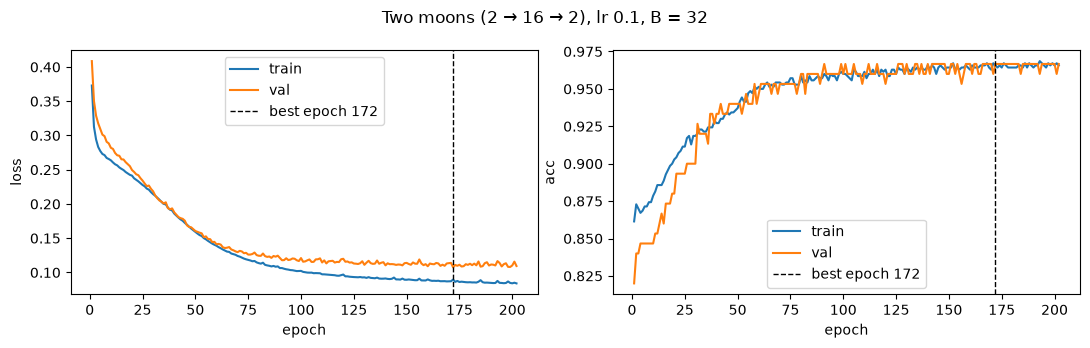

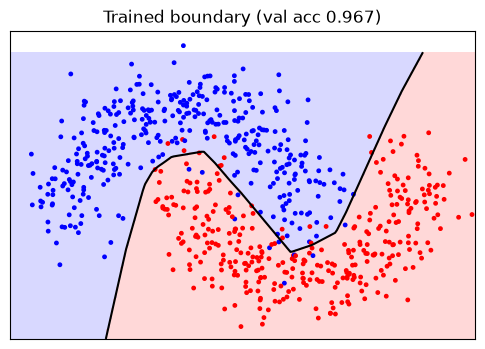

In [132]:
def plot_curves(hist, title):
    # Loss and accuracy per epoch, train vs val. Dashed line = best epoch, the θ that train() restored.
    epochs = range(1, len(hist["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
    for ax, metric in zip(axes, ["loss", "acc"]):
        ax.plot(epochs, hist[f"train_{metric}"], label="train")
        ax.plot(epochs, hist[f"val_{metric}"], label="val")
        ax.axvline(hist["best_epoch"], color="k", ls="--", lw=1, label=f"best epoch {hist['best_epoch']}")
        ax.set_xlabel("epoch"); ax.set_ylabel(metric); ax.legend()
    fig.suptitle(title); plt.tight_layout(); plt.show()


moons_params = init_params(2, 16, 2, torch.Generator().manual_seed(SEED))
t0 = time.time()
moons_hist = train(moons_params, Xtr, ytr, Xva, yva, lr=0.1, batch_size=32, max_epochs=300,
                   gen=torch.Generator().manual_seed(SEED), patience=30, log_every=50)
print(f"trained in {time.time() - t0:.1f} s")
plot_curves(moons_hist, "Two moons (2 → 16 → 2), lr 0.1, B = 32")

# Trained boundary: the same picture as the §3.2 random members, now for the learned θ.
Z = forward(grid, moons_params)[0]                                      # (25000, 2) logits
pred = Z.argmax(dim=1).reshape(gx.shape)                                # (125, 200)
margin = (Z[:, 1] - Z[:, 0]).reshape(gx.shape)                          # (125, 200); boundary where z1 = z0
plt.figure(figsize=(6, 4))
plt.contourf(gx, gy, pred.cpu(), levels=[-0.5, 0.5, 1.5], cmap="bwr", alpha=0.3)
plt.contour(gx, gy, margin.cpu(), levels=[0], colors="k", linewidths=1.5)
plt.scatter(*Xtr.cpu().T, c=ytr.cpu(), cmap="bwr", s=6)
plt.title(f"Trained boundary (val acc {moons_hist['val_acc'][moons_hist['best_epoch'] - 1]:.3f})")
plt.xticks([]); plt.yticks([]); plt.show()

**Reading it (seed 0).**
- **Early stopping fired.** Val loss last improved at epoch 172 (0.1075); 30 epochs without a new best ended training at epoch 202, and θ from epoch 172 was restored. Val accuracy: 96.7%.
- **Mild overfitting, late.** Train and val loss track each other until about epoch 60, then train keeps falling (0.084) while val flattens around 0.11. The gap is small: 16 hidden units on 700 points can't memorise much.
- **Accuracy is coarse, loss is smooth.** With 150 val points, one point = 0.67%, so val accuracy moves in steps and plateaus while val loss still improves. This is why early stopping watches loss.
- **The boundary is piecewise linear.** Straight segments with kinks, one per ReLU switching on or off (§3.2), bent to follow the moons. The few misclassified points sit in the noisy overlap, where no smooth boundary could separate them.

### 6.5 MNIST
The focus problem: 784 → 128 → 10, lr 0.1, B = 64 (782 steps per epoch), up to 50 epochs, early stopping with patience 5. Val loss on 10,000 images is far less noisy than on 150 moons points, so a short patience is enough.

epoch    5 | train loss 0.1186 acc 0.9660 | val loss 0.1436 acc 0.9575
epoch   10 | train loss 0.0567 acc 0.9851 | val loss 0.0953 acc 0.9713
epoch   15 | train loss 0.0333 acc 0.9924 | val loss 0.0850 acc 0.9754
epoch   20 | train loss 0.0222 acc 0.9960 | val loss 0.0793 acc 0.9771
epoch   25 | train loss 0.0155 acc 0.9980 | val loss 0.0802 acc 0.9772
epoch   30 | train loss 0.0122 acc 0.9988 | val loss 0.0792 acc 0.9779
stopped after epoch 32; restored best epoch 27 (val loss 0.0772, val acc 0.9774)
trained in 14.5 s


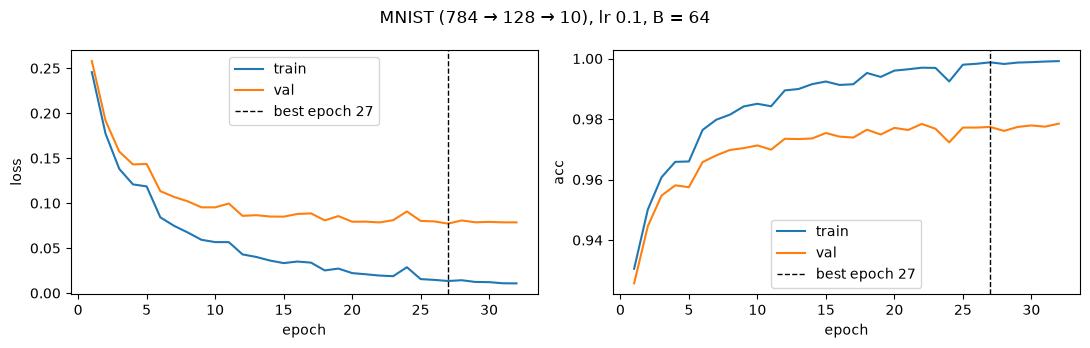

In [133]:
mnist_params = init_params(784, 128, 10, torch.Generator().manual_seed(SEED))
t0 = time.time()
mnist_hist = train(mnist_params, mX_tr, my_tr, mX_va, my_va, lr=0.1, batch_size=64, max_epochs=50,
                   gen=torch.Generator().manual_seed(SEED), patience=5, log_every=5)
print(f"trained in {time.time() - t0:.1f} s")
plot_curves(mnist_hist, "MNIST (784 → 128 → 10), lr 0.1, B = 64")

**Reading it (seed 0).**
- **Early stopping fired, not the cap.** Val loss last improved at epoch 27 (0.0772); 5 epochs without a new best ended training at epoch 32, and θ from epoch 27 was restored. Val accuracy: 97.7%.
- **Overfitting from about epoch 20.** Train loss keeps falling (to ~0.01, 99.9% train acc) but val loss stays flat near 0.08: further training only memorises training images. The widening gap is the symptom; flat val loss is the signal. Early stopping keeps the lowest-val-loss θ.
- **Most of the learning is early.** Val accuracy reaches 97% by epoch 10; the remaining 17 epochs add under 1%.
- **The bumps** (e.g. epoch 24) are SGD noise: each epoch's θ comes from 782 noisy steps, and one unlucky stretch can raise the loss for an epoch. Patience 5 rides over them.

### 6.6 Choosing hyperparameters (on val)
The 6.5 settings (lr 0.1, width 128, B = 64) were a starting point. Here they are chosen on val by a grid search. **The test set is not touched**: it stays an unbiased measurement for §7.

- **Grid:** lr ∈ {0.01, 0.03, 0.1, 0.3} × width ∈ {64, 128, 256, 512} × B ∈ {32, 64, 128} = 48 configs. Fixed: max 50 epochs, patience 5, He init.
- **Patience is fixed, not tuned.** The best θ is always restored, so a longer patience can't do worse; it only trains extra epochs after the minimum. Val loss on 10,000 images is smooth and flattens once overfitting starts (§6.5), so a later, lower minimum is unlikely. Patience only has to ride out noise, and 5 epochs does that here.
- **Selection rule: lowest val loss** at the restored best epoch, the same signal early stopping uses. Val accuracy is reported alongside it.
- **Coarse to fine.** (1) Every config once, seed 0. (2) The 5 best again with seeds 1 and 2, with the winner picked on mean val loss over seeds 0–2. Most configs are clearly worse after one run, so extra seeds go only where the decision is close.
- **Shared seeds.** Every config uses the same seeds, so all of them see the same batch order and differences come from the hyperparameters, not luck in the shuffle (*common random numbers*).
- **Caveat (winner's curse).** Picking the best of 48 on val flatters the winner's val score a little. That is why §7 reports test, not val.

`RUN_SWEEP = True` runs both sweeps (this grid and the edge grid below): about 28 min on an RTX 4080 SUPER, and several times longer on a Colab T4. Leave it `False` to reuse the recorded winners.

In [ ]:
import contextlib
import io
import itertools

RUN_SWEEP = True # Set to True runs all configs (RTX 4080 SUPER, ~28 min); False reuses the recorded winners


LRS, WIDTHS, BATCHES = [0.01, 0.03, 0.1, 0.3], [64, 128, 256, 512], [32, 64, 128]
SWEEP_SEEDS, TOP_K = [0, 1, 2], 5


def run_config(lr, width, batch_size, seed):
    # One MNIST training run -> val loss and val acc at its restored best epoch.
    # The seed fixes both the init draws and the batch order, and every config uses the same seeds.
    params = init_params(784, width, 10, torch.Generator().manual_seed(seed))
    with contextlib.redirect_stdout(io.StringIO()):                   # silence train()'s one-line summary per run
        hist = train(params, mX_tr, my_tr, mX_va, my_va, lr=lr, batch_size=batch_size, max_epochs=50,
                     gen=torch.Generator().manual_seed(seed), patience=5)
    b = hist["best_epoch"]
    return {"val_loss": hist["val_loss"][b - 1], "val_acc": hist["val_acc"][b - 1],
            "best_epoch": b, "epochs": len(hist["val_loss"])}


if RUN_SWEEP:
    # (1) Coarse: all 48 configs, seed 0.
    t0 = time.time()
    coarse = [{"lr": lr, "width": w, "batch_size": bs, **run_config(lr, w, bs, SWEEP_SEEDS[0])}
              for lr, w, bs in itertools.product(LRS, WIDTHS, BATCHES)]
    coarse.sort(key=lambda r: r["val_loss"])
    print(f"(1) coarse: {len(coarse)} configs, seed {SWEEP_SEEDS[0]}, {time.time() - t0:.0f} s")
    print(f"{'rank':>4} {'lr':>5} {'width':>5} {'B':>4} | {'val loss':>8} {'val acc':>7} | best epoch / ran")
    for k, r in enumerate(coarse, 1):
        print(f"{k:4d} {r['lr']:5} {r['width']:5d} {r['batch_size']:4d} | {r['val_loss']:8.4f} {r['val_acc']:7.4f} "
              f"| {r['best_epoch']:3d} / {r['epochs']}")

    # (2) Fine: top TOP_K configs over all seeds; the seed-0 run from (1) is reused.
    t0 = time.time()
    fine = []
    for r in coarse[:TOP_K]:
        runs = [r] + [run_config(r["lr"], r["width"], r["batch_size"], s) for s in SWEEP_SEEDS[1:]]
        loss = torch.tensor([x["val_loss"] for x in runs])            # (3,) one per seed
        acc = torch.tensor([x["val_acc"] for x in runs])              # (3,)
        fine.append({"lr": r["lr"], "width": r["width"], "batch_size": r["batch_size"],
                     "loss_mean": loss.mean().item(), "loss_std": loss.std().item(),
                     "acc_mean": acc.mean().item(), "acc_std": acc.std().item()})
    fine.sort(key=lambda r: r["loss_mean"])
    print(f"\n(2) fine: top {TOP_K}, seeds {SWEEP_SEEDS}, {time.time() - t0:.0f} s")
    print(f"{'lr':>5} {'width':>5} {'B':>4} | {'val loss (mean ± std)':>21} | {'val acc (mean ± std)':>20}")
    for r in fine:
        print(f"{r['lr']:5} {r['width']:5d} {r['batch_size']:4d} | {r['loss_mean']:.4f} ± {r['loss_std']:.4f}       "
              f"| {r['acc_mean']:.4f} ± {r['acc_std']:.4f}")
    BEST = {k: fine[0][k] for k in ("lr", "width", "batch_size")}
else:
    BEST = {"lr": 0.3, "width": 512, "batch_size": 32}   # recorded from the RUN_SWEEP = True run below

print("\nchosen:", BEST)


(1) coarse: 48 configs, seed 0, 789 s
rank    lr width    B | val loss val acc | best epoch / ran
   1   0.3   512   64 |   0.0663  0.9819 |  12 / 17
   2   0.3   512   32 |   0.0675  0.9809 |   7 / 12
   3   0.1   512   32 |   0.0679  0.9802 |  12 / 17
   4   0.1   256   32 |   0.0685  0.9806 |  16 / 21
   5   0.3   256   64 |   0.0688  0.9800 |  12 / 17
   6   0.3   512  128 |   0.0692  0.9804 |  22 / 27
   7   0.3   256  128 |   0.0692  0.9802 |  22 / 27
   8   0.1   512   64 |   0.0702  0.9806 |  27 / 32
   9   0.1   256   64 |   0.0708  0.9801 |  27 / 32
  10   0.3   256   32 |   0.0708  0.9820 |   9 / 14
  11  0.03   512   32 |   0.0710  0.9805 |  35 / 40
  12   0.1   512  128 |   0.0710  0.9807 |  50 / 50
  13  0.03   256   32 |   0.0724  0.9785 |  35 / 40
  14   0.1   256  128 |   0.0743  0.9785 |  35 / 40
  15  0.03   512   64 |   0.0754  0.9787 |  50 / 50
  16   0.3   128   32 |   0.0770  0.9791 |  12 / 17
  17   0.1   128   32 |   0.0772  0.9777 |  16 / 21
  18   0.1   128  

**Reading it.**
- **Width matters most.** At the same lr and B, width 512 and 256 beat 128 in every one of the 12 (lr, B) pairs, and width 64 is near the bottom. More hidden units give ℋ more functions to choose from (§3.2), and at 98% the extra capacity still helps.
- **lr 0.01 never finished.** All 12 of its runs hit the 50-epoch cap, so its rank is partly the cap, not the lr. The grid is biased against small lrs; a fair comparison would need a bigger epoch budget.
- **Bigger lr, earlier stop.** lr 0.3 reaches its best epoch at 7–22; lr 0.03 needs 35–50.
- **B matters least, at a useful lr.** At lr 0.1 and 0.3, changing B usually moves val loss by 0.003 or less (at most 0.006 at widths 128–512), close to seed noise (about ±0.002, from the 3-seed table). At small lrs B matters a lot, but only through the cap: a bigger B means fewer steps per epoch, so those runs end even further from done.
- **The 3-seed stage reorders the top.** On seed 0 alone, B = 64 was first and B = 32 second; on the mean of 3 seeds they swap, 0.0653 vs 0.0662. The gap is smaller than either std, so it is a tie. This is the winner's curse at small scale: part of a seed-0 lead is luck.
- **The winner is on the edge of the grid.** lr 0.3 and width 512 are both the largest values tried, so the best setting could lie beyond them. The next cell checks.

#### Extending past the grid edge
The winner above sits on the edge of the grid: lr 0.3 and width 512 are both the largest values tried, so a better setting could lie beyond them. A second, smaller grid brackets it on every side:

- lr ∈ {0.2, 0.3, 0.5} × width ∈ {512, 768, 1024} × B ∈ {32, 64} = 18 configs. The steps multiply rather than add (log spacing): a hyperparameter's effect depends on its ratio to the current value, not on the difference.
- **5 seeds per config (0–4)**, shared as before. More seeds shrink the luck in each mean, which weakens the winner's curse, and they settle the B = 32 vs 64 tie from the 3-seed stage.
- Same rule: lowest mean val loss. This result replaces `BEST`.

About 13 min on an RTX 4080 SUPER, behind the same `RUN_SWEEP` flag.

In [135]:
EDGE_LRS, EDGE_WIDTHS, EDGE_BATCHES = [0.2, 0.3, 0.5], [512, 768, 1024], [32, 64]
EDGE_SEEDS = [0, 1, 2, 3, 4]

if RUN_SWEEP:
    t0 = time.time()
    edge = []
    for lr, w, bs in itertools.product(EDGE_LRS, EDGE_WIDTHS, EDGE_BATCHES):
        runs = [run_config(lr, w, bs, s) for s in EDGE_SEEDS]
        loss = torch.tensor([x["val_loss"] for x in runs])            # (5,) one per seed
        acc = torch.tensor([x["val_acc"] for x in runs])              # (5,)
        epoch = torch.tensor([x["best_epoch"] for x in runs]).float() # (5,)
        edge.append({"lr": lr, "width": w, "batch_size": bs,
                     "loss_mean": loss.mean().item(), "loss_std": loss.std().item(),
                     "acc_mean": acc.mean().item(), "acc_std": acc.std().item(), "best_epoch": epoch.mean().item()})
    edge.sort(key=lambda r: r["loss_mean"])
    print(f"edge grid: {len(edge)} configs, seeds {EDGE_SEEDS}, {time.time() - t0:.0f} s")
    print(f"{'rank':>4} {'lr':>4} {'width':>5} {'B':>3} | {'val loss (mean ± std)':>21} | {'val acc (mean ± std)':>20} | mean best epoch")
    for k, r in enumerate(edge, 1):
        print(f"{k:4d} {r['lr']:4} {r['width']:5d} {r['batch_size']:3d} | {r['loss_mean']:.4f} ± {r['loss_std']:.4f}       "
              f"| {r['acc_mean']:.4f} ± {r['acc_std']:.4f}     | {r['best_epoch']:5.1f}")
    BEST = {k: edge[0][k] for k in ("lr", "width", "batch_size")}
else:
    BEST = {"lr": 0.3, "width": 768, "batch_size": 32}   # recorded from the RUN_SWEEP = True run below

print("\nchosen:", BEST)


edge grid: 18 configs, seeds [0, 1, 2, 3, 4], 772 s
rank   lr width   B | val loss (mean ± std) | val acc (mean ± std) | mean best epoch
   1  0.3   768  32 | 0.0644 ± 0.0009       | 0.9827 ± 0.0008     |   8.0
   2  0.3  1024  32 | 0.0646 ± 0.0016       | 0.9821 ± 0.0005     |   7.8
   3  0.5  1024  64 | 0.0646 ± 0.0016       | 0.9819 ± 0.0007     |   8.2
   4  0.5   768  64 | 0.0647 ± 0.0010       | 0.9825 ± 0.0010     |   9.4
   5  0.2   768  32 | 0.0648 ± 0.0009       | 0.9825 ± 0.0007     |  10.0
   6  0.2  1024  32 | 0.0651 ± 0.0016       | 0.9815 ± 0.0011     |   8.6
   7  0.3   512  32 | 0.0654 ± 0.0016       | 0.9819 ± 0.0010     |   8.2
   8  0.3   768  64 | 0.0656 ± 0.0012       | 0.9820 ± 0.0010     |  12.6
   9  0.5   512  64 | 0.0658 ± 0.0016       | 0.9821 ± 0.0006     |  10.0
  10  0.2   512  32 | 0.0660 ± 0.0012       | 0.9819 ± 0.0006     |  11.0
  11  0.3  1024  64 | 0.0661 ± 0.0014       | 0.9820 ± 0.0006     |  12.6
  12  0.3   512  64 | 0.0664 ± 0.0006       | 0.9

**Reading it.**
- **Winner: lr 0.3, width 768, B = 32**, val loss 0.0644 ± 0.0009, val acc 98.27% ± 0.08% over 5 seeds. The 6.5 starting point (0.1, 128, 64) scored 0.0772 and 97.74% on seed 0, so tuning adds about 0.5 points of val accuracy (errors fall from 2.26% to 1.73%, about a quarter fewer).
- **The edge problem is closed.** lr 0.3 now has 0.2 and 0.5 on either side, and width 768 has 512 and 1024, and both neighbours are no better. Width 1024 adds nothing over 768.
- **A plateau, not a peak.** The top 6 configs lie within 0.0007 in val loss, less than one seed std. Any of them is as good as any other; the rule picks one. The gain over the first sweep's winner (0.3, 512, 32: 0.0654 here) is also within noise. Further search would mostly fit the val set's noise (winner's curse), so the search stops here.
- **The B tie is settled, and it depends on lr.** With 5 seeds, B = 32 beats B = 64 at lr 0.2 and 0.3, but loses at lr 0.5. A bigger batch averages more examples per step, so its gradient is less noisy and it tolerates a bigger step.
- **Loss and accuracy disagree.** lr 0.5, width 1024, B = 32 ranks 16th of 18 on val loss but ties for the highest val accuracy (98.31%). A large lr pushes logits further apart, so the model is more confident: right more often, but very wrong when it is wrong, and CE punishes confident mistakes heavily. The two metrics rank models differently. The loss was chosen as the rule before the sweep ran, and accuracy is read alongside it (§7).

## 7. Evaluation
Every choice was made on val (§6.6). This section measures the result on the test set and changes nothing.

- **One config goes to test:** `BEST` (lr 0.3, width 768, B = 32). Comparing several finalists on test and keeping the best would move the winner's curse onto test.
- **Five seeds (0–4).** Each one trains on train, early-stops on val, and is evaluated on test once. Results are given as mean ± std, never as the best seed: the spread across seeds is part of the result.
- **Test is for reporting only.** Nothing in this section feeds back into a choice.

MNIST, the focus problem, comes first (7.1–7.4); two moons is the 2D picture (7.5).

### 7.1 Final MNIST models
`BEST`, retrained on seeds 0–4 exactly as in §6.6 (train only, early stopping on val, patience 5). The **val → test gap** checks the §6.6 caveat: if the sweep had overfit the val set, test accuracy would fall clearly below val.

In [136]:
def mean_std(xs):
    # List of floats -> (mean, std). Sample std (n - 1), as in §6.6.
    t = torch.tensor(xs)
    return t.mean().item(), t.std().item()


FINAL_SEEDS = [0, 1, 2, 3, 4]
final = []   # one dict per seed: trained params plus its val and test scores
t0 = time.time()
for seed in FINAL_SEEDS:
    params = init_params(784, BEST["width"], 10, torch.Generator().manual_seed(seed))
    print(f"seed {seed}:", end=" ")
    hist = train(params, mX_tr, my_tr, mX_va, my_va, lr=BEST["lr"], batch_size=BEST["batch_size"], max_epochs=50,
                 gen=torch.Generator().manual_seed(seed), patience=5)
    final.append({"seed": seed, "params": params, "best_epoch": hist["best_epoch"],
                  "val": evaluate(mX_va, my_va, params), "test": evaluate(mX_te, my_te, params)})   # (loss, acc) each; one test evaluation per seed
print(f"trained in {time.time() - t0:.0f} s\n")

print(f"{'seed':>4} {'best epoch':>10} | {'val loss':>8} {'val acc':>7} | {'test loss':>9} {'test acc':>8}")
for r in final:
    print(f"{r['seed']:4d} {r['best_epoch']:10d} | {r['val'][0]:8.4f} {r['val'][1]:7.4f} | {r['test'][0]:9.4f} {r['test'][1]:8.4f}")
stats = {f"{split}_{m}": mean_std([r[split][j] for r in final])
         for split in ("val", "test") for j, m in enumerate(("loss", "acc"))}
print("mean ± std: " + " | ".join(f"{k} {m:.4f} ± {s:.4f}" for k, (m, s) in stats.items()))
print(f"val → test gap in accuracy: {stats['val_acc'][0] - stats['test_acc'][0]:+.4f}")


seed 0: stopped after epoch 12; restored best epoch 7 (val loss 0.0637, val acc 0.9820)
seed 1: stopped after epoch 12; restored best epoch 7 (val loss 0.0657, val acc 0.9820)
seed 2: stopped after epoch 15; restored best epoch 10 (val loss 0.0645, val acc 0.9837)
seed 3: stopped after epoch 14; restored best epoch 9 (val loss 0.0645, val acc 0.9832)
seed 4: stopped after epoch 12; restored best epoch 7 (val loss 0.0634, val acc 0.9824)
trained in 49 s

seed best epoch | val loss val acc | test loss test acc
   0          7 |   0.0637  0.9820 |    0.0569   0.9832
   1          7 |   0.0657  0.9820 |    0.0574   0.9825
   2         10 |   0.0645  0.9837 |    0.0566   0.9839
   3          9 |   0.0645  0.9832 |    0.0557   0.9846
   4          7 |   0.0634  0.9824 |    0.0565   0.9831
mean ± std: val_loss 0.0644 ± 0.0009 | val_acc 0.9827 ± 0.0008 | test_loss 0.0566 ± 0.0006 | test_acc 0.9835 ± 0.0008
val → test gap in accuracy: -0.0008


**Reading it.**
- **Test accuracy 98.35% ± 0.08%** over 5 seeds (test loss 0.0566 ± 0.0006). The spread is small: any one of the 5 runs tells the same story.
- **No sign that the sweep overfit the val set.** Test accuracy is 0.08 points *above* val (98.35% vs 98.27%), inside one seed std. A gap this size, in either direction, is the noise between two samples of 10,000 images. The winner's-curse bias from 66 configs is too small to see here.
- **Reproducible.** The val scores match the §6.6 edge table to the last digit (0.0644 ± 0.0009, 98.27% ± 0.08%): same seeds and same code give the same runs. Best epochs 7–10, as in the sweep.

### 7.2 Baselines and a reference
Accuracy alone has no scale. The **baselines** are floors: each one removes one ingredient to show what it contributes.

| Baseline | What it does | What it answers |
|---|---|---|
| Majority class | Always predicts the most common training digit | The floor from the class balance alone |
| Untrained network | Our model at width 768 with random He-init θ, no training; mean ± std over 100 draws | The architecture alone, with no learning (the members of ℋ before training, §3.2) |
| Nearest-mean digit | Averages each digit's training images into one template, then labels a test image with its closest template (sum of squared pixel differences) | A hand rule: "it's a 3 if it looks like the average 3". No loss and no gradients, so it shows what learning adds over a simple rule |

The **reference** is not a floor. sklearn's `MLPClassifier` trained on the same recipe checks that our from-scratch implementation reaches what a standard library reaches. It is used for this comparison only! Its settings match ours: one hidden layer of 768 ReLU units, plain SGD (`momentum=0`), lr 0.3, B = 32, no weight decay (`alpha=0`), trained on our 50,000 training images. Early stopping is off, and it trains for a fixed number of epochs, our mean best epoch from 7.1. It runs on the CPU and uses 1 seed, because it is a single reference point.

MNIST test accuracy
majority class (always 1)                    0.1135
untrained network (100 random θ)             0.1036 ± 0.0268
nearest-mean digit                           0.8199
ours (5 seeds)                               0.9835 ± 0.0008
sklearn MLPClassifier reference (8 epochs, 1 seed) 0.9828   [44 s on CPU]


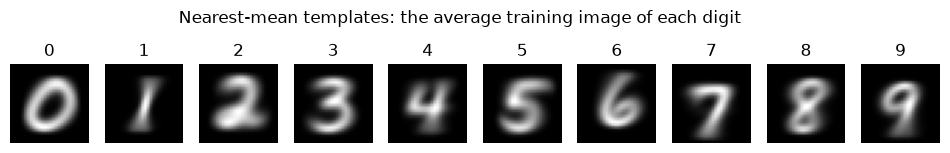

In [137]:
import warnings
from sklearn.exceptions import ConvergenceWarning
from sklearn.neural_network import MLPClassifier   # reference only (7.2); not used by our model

# Majority class.
majority = torch.bincount(my_tr).argmax()                                           # most common training digit
acc_majority = (my_te == majority).float().mean().item()

# Untrained network: 100 random members of ℋ at the final width.
g = torch.Generator().manual_seed(SEED)
acc_untrained = mean_std([evaluate(mX_te, my_te, init_params(784, BEST["width"], 10, g))[1] for _ in range(100)])

# Nearest-mean digit: one template per digit, then the closest template wins.
templates = torch.stack([mX_tr[my_tr == k].mean(dim=0) for k in range(10)])        # (10, 784) the average image of each digit
dist = torch.stack([((mX_te - t) ** 2).sum(dim=1) for t in templates], dim=1)       # (10000, 784) -> (10000,) per template -> (10000, 10)
acc_nearest = (dist.argmin(dim=1) == my_te).float().mean().item()

# Reference: sklearn on the same recipe, for our mean best epoch (see markdown).
sk_epochs = round(sum(r["best_epoch"] for r in final) / len(final))
clf = MLPClassifier(hidden_layer_sizes=(BEST["width"],), activation="relu", solver="sgd",
                    learning_rate_init=BEST["lr"], batch_size=BEST["batch_size"], momentum=0, alpha=0,
                    max_iter=sk_epochs, early_stopping=False, shuffle=True, random_state=SEED)
t0 = time.time()
with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)                              # expected: we stop it at a fixed epoch count on purpose
    clf.fit(mX_tr.cpu().numpy(), my_tr.cpu().numpy())
acc_sklearn = (clf.predict(mX_te.cpu().numpy()) == my_te.cpu().numpy()).mean()      # accuracy computed by hand, not sklearn.metrics
sk_time = time.time() - t0

print("MNIST test accuracy")
print(f"{'majority class (always ' + str(int(majority)) + ')':<44} {acc_majority:.4f}")
print(f"{'untrained network (100 random θ)':<44} {acc_untrained[0]:.4f} ± {acc_untrained[1]:.4f}")
print(f"{'nearest-mean digit':<44} {acc_nearest:.4f}")
print(f"{'ours (5 seeds)':<44} {stats['test_acc'][0]:.4f} ± {stats['test_acc'][1]:.4f}")
print(f"{f'sklearn MLPClassifier reference ({sk_epochs} epochs, 1 seed)':<44} {acc_sklearn:.4f}   [{sk_time:.0f} s on CPU]")

fig, axes = plt.subplots(1, 10, figsize=(12, 1.6))
for k, ax in enumerate(axes):
    ax.imshow(templates[k].reshape(28, 28).cpu(), cmap="gray"); ax.set_title(k); ax.axis("off")
fig.suptitle("Nearest-mean templates: the average training image of each digit", y=1.08); plt.show()


**Reading it.**
- **Learning, not the architecture, does the work.** The untrained network scores 10.4% ± 2.7%, no better than guessing (10%) or always answering "1" (11.4%). The same architecture after training: 98.35%.
- **The hand rule reaches 82.0%.** The templates above are blurry averages, so a digit drawn slanted, thick or off-centre lands closer to the wrong template. Learning cuts the error rate from 18.0% to 1.65%, about 11 times fewer errors. That is the case for learning over a hand-written rule.
- **Our implementation matches the library.** sklearn reaches 98.28% against our 98.35% ± 0.08%: within one std of our seeds, despite its different init and fixed epoch count. The gradient check (§5.3) tests one backward pass; this tests the whole pipeline (data, loop, early stopping) against an independent implementation.

### 7.3 Where the errors are
**Confusion matrix** (rows = true digit, columns = prediction). The counts are added up over all 5 seeds (5 × 10,000 = 50,000 test predictions), so no single run decides which errors appear. The colour shows errors only (the diagonal is left uncoloured), since the ~5,000 correct predictions per digit would otherwise wash out the scale. **Per-class accuracy** is computed per seed, then given as mean ± std.

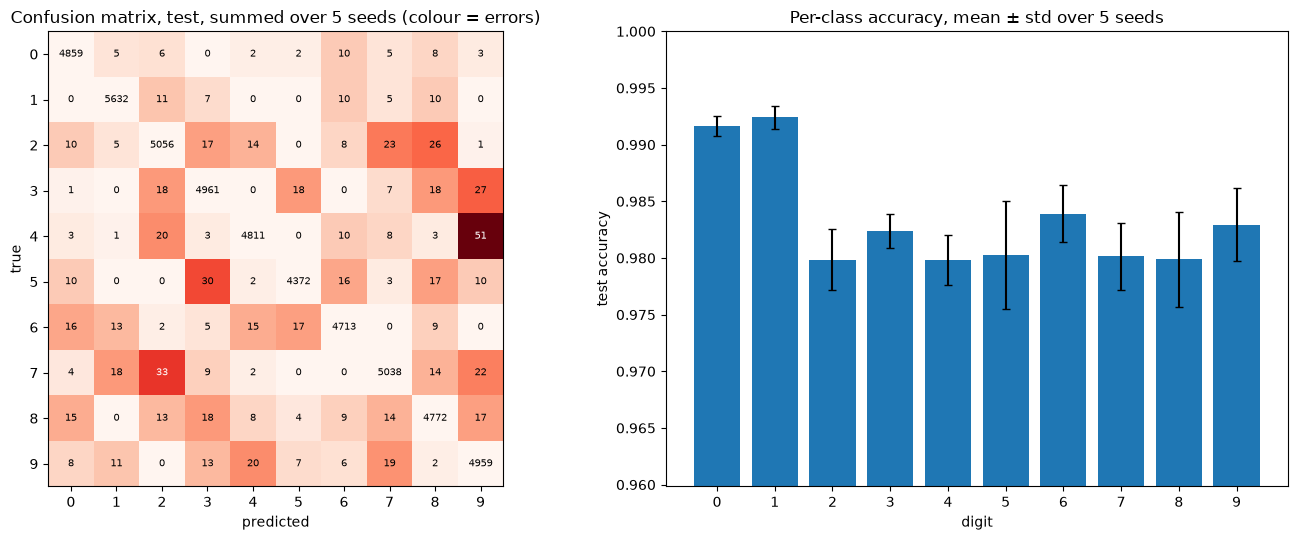

per-class accuracy: 0: 0.9916±0.0009  1: 0.9924±0.0010  2: 0.9798±0.0027  3: 0.9824±0.0015  4: 0.9798±0.0022  5: 0.9803±0.0048  6: 0.9839±0.0025  7: 0.9802±0.0030  8: 0.9799±0.0042  9: 0.9830±0.0032
most common errors (summed over 5 seeds):
  true 4 → predicted 9: 51  (row total 4910)
  true 7 → predicted 2: 33  (row total 5140)
  true 5 → predicted 3: 30  (row total 4460)
  true 3 → predicted 9: 27  (row total 5050)
  true 2 → predicted 8: 26  (row total 5160)
  true 2 → predicted 7: 23  (row total 5160)


In [138]:
def predict(X, params):
    # (N, d_in) -> (N,) predicted class: argmax of the logits (§3.2).
    return forward(X, params)[0].argmax(dim=1)


def confusion(y, pred, K=10):
    # (N,) true, (N,) predicted -> (K, K) counts; row = true class, column = predicted.
    # Each pair (t, p) becomes one index t·K + p in 0..K²−1, so one bincount fills every cell.
    return torch.bincount(y * K + pred, minlength=K * K).reshape(K, K)


cms = torch.stack([confusion(my_te, predict(mX_te, r["params"])) for r in final]).cpu()   # (5, 10, 10) one matrix per seed
cm = cms.sum(dim=0)                                                                         # (10, 10) summed over seeds
class_acc = cms.diagonal(dim1=1, dim2=2) / cms.sum(dim=2)                                   # (5, 10) correct / total, per seed and digit
acc_mean, acc_std = class_acc.mean(dim=0), class_acc.std(dim=0)                             # (10,) each

errors = cm.clone()
errors.fill_diagonal_(0)                                                                    # (10, 10) off-diagonal only
fig, (a, b) = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={"width_ratios": [1.15, 1]})
a.imshow(errors, cmap="Reds")
for t in range(10):
    for p in range(10):
        a.text(p, t, int(cm[t, p]), ha="center", va="center", fontsize=7,
               color="white" if errors[t, p] > errors.max() * 0.6 else "black")
a.set_xticks(range(10)); a.set_yticks(range(10))
a.set_xlabel("predicted"); a.set_ylabel("true")
a.set_title("Confusion matrix, test, summed over 5 seeds (colour = errors)")
b.bar(range(10), acc_mean, yerr=acc_std, capsize=3)
b.set_ylim(acc_mean.min() - 0.02, 1.0); b.set_xticks(range(10))
b.set_xlabel("digit"); b.set_ylabel("test accuracy"); b.set_title("Per-class accuracy, mean ± std over 5 seeds")
plt.tight_layout(); plt.show()

print("per-class accuracy:", "  ".join(f"{k}: {m:.4f}±{s:.4f}" for k, (m, s) in enumerate(zip(acc_mean, acc_std))))
top = errors.flatten().topk(6)                                                              # 6 largest off-diagonal cells
print("most common errors (summed over 5 seeds):")
for n, i in zip(top.values.tolist(), top.indices.tolist()):
    print(f"  true {i // 10} → predicted {i % 10}: {n}  (row total {int(cm[i // 10].sum())})")


**Reading it.**
- **The errors are digit pairs that share strokes.** The largest cells: 4 → 9 (51), 7 → 2 (33), 5 → 3 (30), 3 → 9 (27), 2 → 8 (26), 2 → 7 (23). A 4 with a closed top is a 9; a 7 with a curved foot is a 2; a 5 and a 3 differ only in the top-left stroke.
- **0 and 1 are easiest (99.2%)**: no other digit shares their shapes. 2, 4, 5, 7 and 8 are hardest (about 98.0%).
- **Confusion is one-way.** 4 → 9 happens 51 times but 9 → 4 only 20; 7 → 2 33 times but 2 → 7 23. The model has a preferred reading for each ambiguous shape.
- **5 and 8 vary most between seeds (std 0.4–0.5 points).** 5 is also the rarest digit in test (892 images), so each error moves its accuracy more.
- **Future work, from these errors.** The confused pairs differ by one small stroke in one place. The MLP sees 784 separate pixels, so it must learn each stroke at each position on its own, and a shifted or slanted digit is a new pattern to it. Two targeted fixes: **data augmentation** (train on small shifts and rotations of each image), or a **convolutional network**, which reuses the same stroke detectors at every position. Both target this failure mode directly; more of the same data would not.

### 7.4 Loss vs task objective
**Expected behaviour.** Input: one 28 × 28 greyscale image of a handwritten digit. Output: the digit. The model outputs 10 probabilities (softmax of the logits), and its prediction is the most probable class.

**The ideal comparison** between output and target is 0–1: right or wrong per image, i.e. accuracy. It *is* used, at the val stage (recorded every epoch, §6.2, and read alongside loss in §6.6) and at the test stage (this section). It is **not** used in training: a small change to θ almost never flips a prediction, so the 0–1 loss is flat almost everywhere (gradient 0) and jumps where a prediction flips. Backprop has no slope to follow. So training minimises cross-entropy instead, a smooth stand-in: −log p(true class).

**Where the two differ.** CE rewards confidence, not just correctness:

| Case | Accuracy | CE = −log p(true) |
|---|---|---|
| Right, confident: p(true) = 0.99 | 1 | 0.01 |
| Right but unsure: p(true) = 0.40, still the argmax | 1 | 0.92 |
| Wrong, nearly right: p(true) = 0.49 vs p(pred) = 0.51 | 0 | 0.71 |
| Wrong, confident: p(true) = 0.001 | 0 | 6.91 |

Accuracy counts the two wrong rows the same; CE scores the confident one about 10 times worse. So a few confident mistakes can dominate the loss, and the loss can fall while accuracy stays put, for example by growing confidence on images that are already right. The two galleries show both ends, from the seed-0 model:

- **Most wrong:** the errors with the highest CE (lowest p(true)). These dominate the loss.
- **Most unsure:** the predictions, right or wrong, with the smallest gap between the top two probabilities. The model is split between two digits.

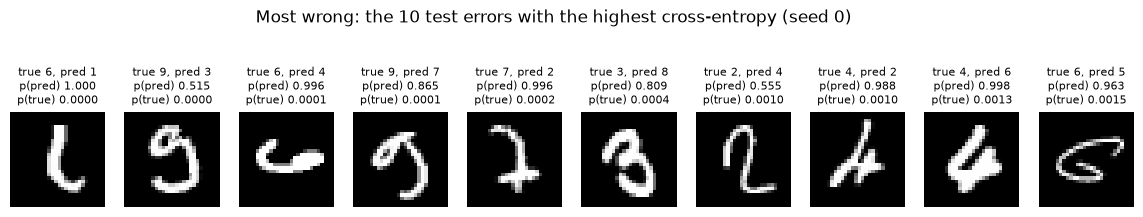

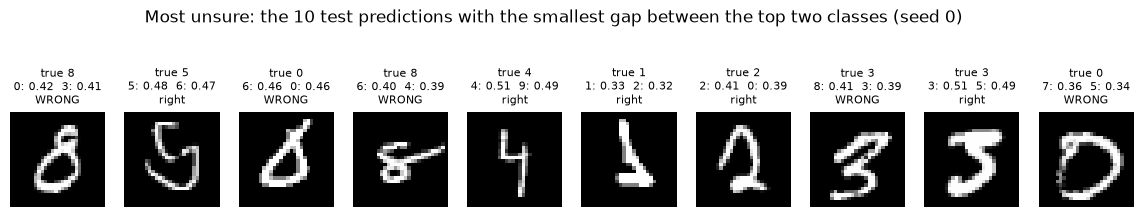

seed 0: 168 of 10000 test images wrong (1.68%)
mean CE: right 0.0092 | wrong 2.8490
share of the total test loss from the wrong images: 84.1%
wrong with p(pred) > 0.9 (confident mistakes): 54
right with p(pred) < 0.6 (unsure but right): 35


In [139]:
Z = forward(mX_te, final[0]["params"])[0]                    # (10000, 10) logits, seed-0 model
P = softmax(Z)                                                # (10000, 10)
pred = Z.argmax(dim=1)                                        # (10000,)
rows = torch.arange(len(my_te), device=device)
loss_i = -log_softmax(Z)[rows, my_te]                         # (10000,) CE per image, from log_softmax (stable, §4.2)
wrong = pred != my_te                                         # (10000,) bool
top2 = P.topk(2, dim=1)                                       # values and indices, each (10000, 2)
gap = top2.values[:, 0] - top2.values[:, 1]                   # (10000,) small gap = unsure


def gallery(idx, label, title):
    # One test image per panel, with a caption from label(i).
    fig, axes = plt.subplots(1, len(idx), figsize=(1.45 * len(idx), 2.4))
    for ax, i in zip(axes, idx.tolist()):
        ax.imshow(mX_te[i].reshape(28, 28).cpu(), cmap="gray")
        ax.set_title(label(i), fontsize=8); ax.axis("off")
    fig.suptitle(title, y=1.12); plt.show()


wrong_idx = wrong.nonzero().squeeze(1)                        # (n_wrong,) indices of the errors
most_wrong = wrong_idx[loss_i[wrong_idx].topk(10).indices]    # (10,) the 10 errors with the highest CE
gallery(most_wrong,
        lambda i: f"true {int(my_te[i])}, pred {int(pred[i])}\np(pred) {P[i, pred[i]]:.3f}\np(true) {P[i, my_te[i]]:.4f}",
        "Most wrong: the 10 test errors with the highest cross-entropy (seed 0)")

most_unsure = gap.topk(10, largest=False).indices             # (10,) the smallest top-2 gaps
gallery(most_unsure,
        lambda i: f"true {int(my_te[i])}\n{int(top2.indices[i, 0])}: {top2.values[i, 0]:.2f}  "
                  f"{int(top2.indices[i, 1])}: {top2.values[i, 1]:.2f}\n{'right' if not wrong[i] else 'WRONG'}",
        "Most unsure: the 10 test predictions with the smallest gap between the top two classes (seed 0)")

n_wrong = int(wrong.sum())
print(f"seed 0: {n_wrong} of 10000 test images wrong ({n_wrong / 100:.2f}%)")
print(f"mean CE: right {loss_i[~wrong].mean():.4f} | wrong {loss_i[wrong].mean():.4f}")
print(f"share of the total test loss from the wrong images: {loss_i[wrong].sum() / loss_i.sum():.1%}")
print(f"wrong with p(pred) > 0.9 (confident mistakes): {int((wrong & (P.max(dim=1).values > 0.9)).sum())}")
print(f"right with p(pred) < 0.6 (unsure but right): {int((~wrong & (P.max(dim=1).values < 0.6)).sum())}")


**Reading it.**
- **1.68% of the test images carry 84% of the test loss.** Mean CE on a wrong image is 2.85, against 0.0092 on a right one, about 300 times more. The test loss mostly measures *how badly* the model fails on a few images, not *how often* it is right.
- **About a third of the errors are confident.** 54 of the 168 mistakes have p(pred) > 0.9: the model's own probabilities give no warning.
- **"Most wrong" is a mix.** Some are hard for a person too: the first (labelled 6) reads as an l or a 1, and the third and eighth are malformed. Others a person reads easily, like the 9 (second), the 3 (sixth) and the 2 (seventh): these are real model failures on unusual slant or stroke thickness. CE is largest exactly here, so these images pull hardest on training. Where a label is genuinely ambiguous, CE still pushes the model to be confident about it.
- **"Most unsure" are coin flips.** 5 of the 10 are right and 5 wrong, which is what top-two probabilities near 0.5 mean. Some are shapes a person would hesitate over too like the 0 (third) that could be a 6 or a 0.

### 7.5 Two moons
Moons is the 2D picture (not the focus problem), so it isn't tuned. The 6.4 settings (2 → 16 → 2, lr 0.1, B = 32, patience 30) are retrained on seeds 0–4. All 5 seeds train on the same data split; only the random starting weights and the order of the mini-batches differ.

Three figures: the 5 trained boundaries on the test points, seed 0's confidence across the plane, and trained members of ℋ at widths 2, 4, 16 and 64 (§3.2).

seed 0: stopped after epoch 202; restored best epoch 172 (val loss 0.1075, val acc 0.9667)
seed 1: stopped after epoch 211; restored best epoch 181 (val loss 0.1118, val acc 0.9667)
seed 2: stopped after epoch 198; restored best epoch 168 (val loss 0.1094, val acc 0.9667)
seed 3: stopped after epoch 223; restored best epoch 193 (val loss 0.1131, val acc 0.9667)
seed 4: stopped after epoch 192; restored best epoch 162 (val loss 0.1129, val acc 0.9667)

moons test acc 0.9773 ± 0.0037 (5 seeds) | majority-class baseline 0.4000


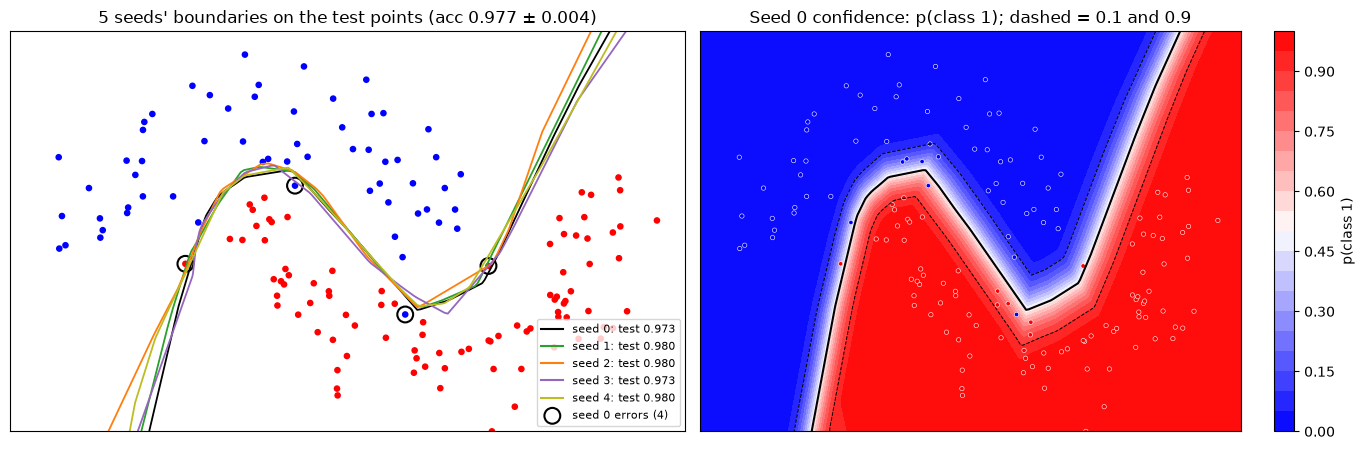

width 2: stopped after epoch 300; restored best epoch 292 (val loss 0.2600, val acc 0.8800)
width 4: stopped after epoch 260; restored best epoch 230 (val loss 0.1233, val acc 0.9667)
width 16: stopped after epoch 202; restored best epoch 172 (val loss 0.1075, val acc 0.9667)
width 64: stopped after epoch 190; restored best epoch 160 (val loss 0.1039, val acc 0.9667)


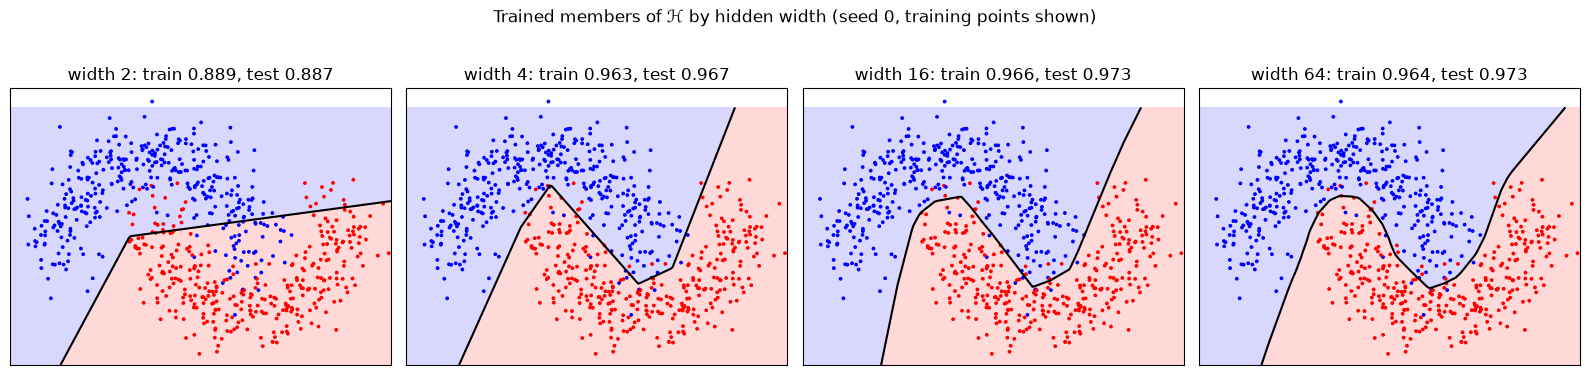

In [140]:
moons_final = []
for seed in FINAL_SEEDS:
    params = init_params(2, 16, 2, torch.Generator().manual_seed(seed))
    print(f"seed {seed}:", end=" ")
    train(params, Xtr, ytr, Xva, yva, lr=0.1, batch_size=32, max_epochs=300,
          gen=torch.Generator().manual_seed(seed), patience=30)
    moons_final.append({"params": params, "test": evaluate(Xte, yte, params)})
m_acc = mean_std([r["test"][1] for r in moons_final])
m_majority = (yte == torch.bincount(ytr).argmax()).float().mean().item()
print(f"\nmoons test acc {m_acc[0]:.4f} ± {m_acc[1]:.4f} (5 seeds) | majority-class baseline {m_majority:.4f}")

fig, (a, b) = plt.subplots(1, 2, figsize=(14, 4.6))
a.scatter(*Xte.cpu().T, c=yte.cpu(), cmap="bwr", s=14)
for seed, r, col in zip(FINAL_SEEDS, moons_final, ["k", "tab:green", "tab:orange", "tab:purple", "tab:olive"]):
    Z = forward(grid, r["params"])[0]                                     # (25000, 2) logits
    a.contour(gx, gy, (Z[:, 1] - Z[:, 0]).reshape(gx.shape).cpu(), levels=[0], colors=[col], linewidths=1.3)
    a.plot([], [], color=col, label=f"seed {seed}: test {r['test'][1]:.3f}")   # legend entry; contour lines have none
wrong0 = predict(Xte, moons_final[0]["params"]) != yte                  # (150,) seed-0 errors
a.scatter(*Xte[wrong0].cpu().T, s=130, facecolors="none", edgecolors="k", linewidths=1.5,
          label=f"seed 0 errors ({int(wrong0.sum())})")
a.legend(fontsize=8, loc="lower right"); a.set_xticks([]); a.set_yticks([])
a.set_title(f"5 seeds' boundaries on the test points (acc {m_acc[0]:.3f} ± {m_acc[1]:.3f})")

p1 = softmax(forward(grid, moons_final[0]["params"])[0])[:, 1].reshape(gx.shape).cpu()   # (125, 200) p(class 1)
cf = b.contourf(gx, gy, p1, levels=20, cmap="bwr", vmin=0, vmax=1)
fig.colorbar(cf, ax=b, label="p(class 1)")
b.contour(gx, gy, p1, levels=[0.1, 0.5, 0.9], colors="k", linewidths=[0.7, 1.5, 0.7], linestyles=["--", "-", "--"])
b.scatter(*Xte.cpu().T, c=yte.cpu(), cmap="bwr", s=10, edgecolors="w", linewidths=0.4)
b.set_xticks([]); b.set_yticks([]); b.set_title("Seed 0 confidence: p(class 1); dashed = 0.1 and 0.9")
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 4, figsize=(16, 3.6))
for ax, w in zip(axes, [2, 4, 16, 64]):
    params = init_params(2, w, 2, torch.Generator().manual_seed(SEED))
    print(f"width {w}:", end=" ")
    train(params, Xtr, ytr, Xva, yva, lr=0.1, batch_size=32, max_epochs=300,
          gen=torch.Generator().manual_seed(SEED), patience=30)
    Z = forward(grid, params)[0]                                          # (25000, 2)
    ax.contourf(gx, gy, Z.argmax(dim=1).reshape(gx.shape).cpu(), levels=[-0.5, 0.5, 1.5], cmap="bwr", alpha=0.3)
    ax.contour(gx, gy, (Z[:, 1] - Z[:, 0]).reshape(gx.shape).cpu(), levels=[0], colors="k", linewidths=1.5)
    ax.scatter(*Xtr.cpu().T, c=ytr.cpu(), cmap="bwr", s=3)
    ax.set_title(f"width {w}: train {evaluate(Xtr, ytr, params)[1]:.3f}, test {evaluate(Xte, yte, params)[1]:.3f}")
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Trained members of ℋ by hidden width (seed 0, training points shown)", y=1.03); plt.tight_layout(); plt.show()


**Reading it.**
- **Test accuracy 97.7% ± 0.4%** over 5 seeds. The majority-class baseline is 40.0% because the training majority (class 0, 364 of 700) happens to be the minority of this 150-point test split (60 of 150). The moons are balanced by construction, so 50% is the fairer reference.
- **The boundaries agree where the data is, and fan out where it isn't.** Between the moons the 5 lines nearly coincide; in the empty top-right and bottom-left corners they split apart. Yet each model is close to 100% confident there (right). 
- **The errors sit on the boundary**, inside the overlap (seed 0: 4 of 150), where the confidence is between 0.1 and 0.9. Moons errors come from the noise in the data and the model is unsure about them, unlike MNIST's 54 confident mistakes.
- **Width:**
  - Each ReLU unit adds one straight fold line, so the boundary is made of straight pieces.
  - With 2 units it can't bend round the moons: train 88.9%, test 88.7%. Train is low too, so this is underfitting (too little capacity), not overfitting.
  - 4 units already give the right shape (96.7%).
  - 16 and 64 both reach 97.3% test; 64 is smoother but no more accurate.
  - Capacity helps until the boundary can follow the data, then stops. That is the same plateau as MNIST widths 768–1024 in §6.6.

### 7.6 Results summary
Test set, seeds 0–4 unless stated.

| MNIST (784 → 768 → 10) | Test accuracy |
|---|---|
| Majority class (always 1) | 11.35% |
| Untrained network (100 random θ) | 10.4% ± 2.7% |
| Nearest-mean digit (hand rule) | 81.99% |
| **Ours** | **98.35% ± 0.08%** (test loss 0.0566 ± 0.0006) |
| sklearn `MLPClassifier`, same recipe (reference, 1 seed) | 98.28% |

- **Val → test:** 98.27% → 98.35%, no sign of overfitting to val.
- **Hardest digits:** 2, 4, 5, 7 and 8 (about 98.0%). **Most common error:** 4 → 9.
- **Loss vs objective:** 1.68% of test images carry 84% of the test loss; 54 of 168 errors (seed 0) are confident (p > 0.9).
- **Two moons (2 → 16 → 2):** 97.7% ± 0.4% (majority class 40.0%).